# Laneless Karalakou PPO

Train an ego vehicle in the custom lane-free highway-env extension using the best reward family from Karalakou et al.: **Fields + Zones + Overtake + Collision Avoidance**.

The simulator still comes from `laneless highway env/lane_free_env.py`. This notebook adds only an RL reward wrapper and training/evaluation code.

If an import fails, install the dependencies in the selected notebook interpreter:

```python
# !python -m pip install -U stable-baselines3[extra] gymnasium highway-env torch numpy pandas matplotlib pygame
```

In [ ]:
from __future__ import annotations

import os
import sys
import time
import warnings
from pathlib import Path
from typing import Any, Optional

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy
import sympy.core  # Eager import for PyTorch/SB3 symbolic-shape compatibility.
import torch
from IPython.display import display
from stable_baselines3 import DDPG, PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise, VectorizedActionNoise
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv


def find_project_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "laneless highway env" / "lane_free_env.py").exists():
            return candidate
        nested = candidate / "highway-rl-decision-making"
        if (nested / "laneless highway env" / "lane_free_env.py").exists():
            return nested
    raise RuntimeError("Could not find the project root containing 'laneless highway env/lane_free_env.py'.")


PROJECT_ROOT = find_project_root()
LANE_FREE_DIR = PROJECT_ROOT / "laneless highway env"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "lanelessKaralakou"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

lane_free_dir_str = str(LANE_FREE_DIR)
if lane_free_dir_str not in sys.path:
    sys.path.insert(0, lane_free_dir_str)

import lane_free_env  # noqa: F401: registers lane-free-v0

warnings.filterwarnings("ignore", message=r"OSQP exited.*")
RUNNING_IN_NOTEBOOK = "ipykernel" in sys.modules

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
    torch.backends.cudnn.benchmark = True
    torch.set_num_threads(max(1, int(os.environ.get("TORCH_NUM_THREADS", "1"))))

print("Project root:", PROJECT_ROOT)
print("Lane-free env dir:", LANE_FREE_DIR)
print("Device:", DEVICE)

## Karalakou Best Reward Wrapper

The paper's best-performing reward function combines:

- desired longitudinal speed cost `cx`
- lateral target/zone cost `cy`
- potential-field collision-risk cost `cf`
- collision penalty `rc`
- lateral acceleration cost `cay`
- overtake bonus `ro`

The wrapper below replaces the environment reward during PPO training without changing the simulator source code.

In [14]:
class KaralakouRewardWrapper(gym.Wrapper):
    """Reward wrapper for Fields + Zones + Overtake + Collision Avoidance."""

    def __init__(self, env: gym.Env, reward_config: Optional[dict[str, float]] = None) -> None:
        super().__init__(env)
        self.reward_config = {
            "epsilon_r": 0.4,
            "wx": 1.0,
            "wy": 0.65,
            "wf": 1.0,
            "collision_penalty": -2.5,
            "way": 0.0,
            "overtake_bonus": 0.5,
            "timegap": 0.7,
            "ego_desired_speed": 20.0,
            "field_magnitude": 0.5,
            "field_px": 2.0,
            "field_py": 2.0,
            "field_pt": 1.0,
            "zone_margin": 0.15,
        }
        if reward_config:
            self.reward_config.update(reward_config)

    @property
    def base_env(self):
        return self.env.unwrapped

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.base_env.vehicle.desired_speed = float(self.reward_config["ego_desired_speed"])
        return self._augment_observation(self.base_env._observe()), info

    def step(self, action):
        previous_dx = self._relative_dx_by_vehicle()
        obs, _, terminated, truncated, info = self.env.step(action)
        reward, components = self._karalakou_reward(previous_dx)

        info = dict(info)
        info.update({f"karalakou_{key}": value for key, value in components.items()})
        return self._augment_observation(obs), reward, terminated, truncated, info

    def _augment_observation(self, obs: np.ndarray) -> np.ndarray:
        """Put ego lateral y into the otherwise-empty first ego-row slot; hide target_y."""
        augmented = np.asarray(obs, dtype=np.float32).reshape(-1).copy()
        if augmented.size < 2:
            return augmented
        base = self.base_env
        road_width = max(float(base.config["road_width"]), 1e-6)
        ego_y = float(base.vehicle.position[1])
        augmented[0] = np.clip((ego_y - 0.5 * road_width) / (0.5 * road_width), -1.0, 1.0)
        augmented[1] = 0.0
        return augmented.astype(np.float32)

    def _relative_dx_by_vehicle(self) -> dict[int, float]:
        base = self.base_env
        ego = base.vehicle
        return {
            id(vehicle): base._signed_distance(ego.position[0], vehicle.position[0])
            for vehicle in base.road.vehicles
            if vehicle is not ego
        }

    def _karalakou_reward(self, previous_dx: dict[int, float]) -> tuple[float, dict[str, float]]:
        base = self.base_env
        ego = base.vehicle
        cfg = self.reward_config

        target_y, target_speed, zone_found = self._lateral_target_and_speed()
        cx = abs(ego.vx - target_speed) / max(target_speed, 1e-6)
        cy = abs(float(ego.position[1]) - target_y) / max(float(base.config["road_width"]), 1e-6)
        cf = self._potential_field_cost()
        cay = self._lateral_acceleration_cost()
        overtakes = self._overtake_count(previous_dx)

        denom = cfg["epsilon_r"] + cfg["wx"] * cx + cfg["wy"] * cy + cfg["wf"] * cf + cfg.get("way", 0.0) * cay
        reward = cfg["epsilon_r"] / max(denom, 1e-9)
        if bool(base._last_ego_collision):
            reward += cfg["collision_penalty"]
        elif overtakes > 0:
            reward += cfg["overtake_bonus"] * min(overtakes, 1)

        components = {
            "reward": float(reward),
            "cx": float(cx),
            "cy": float(cy),
            "cf": float(cf),
            "cay": float(cay),
            "ay": float(self._ego_lateral_acceleration()),
            "target_y": float(target_y),
            "target_speed": float(target_speed),
            "zone_found": float(zone_found),
            "overtakes": float(overtakes),
            "ego_collision": float(base._last_ego_collision),
        }
        return float(reward), components

    def _ego_lateral_acceleration(self) -> float:
        base = self.base_env
        if len(base._last_accelerations) == 0:
            return 0.0
        return float(base._last_accelerations[0, 1])

    def _lateral_acceleration_cost(self) -> float:
        base = self.base_env
        bounds = base.config["bounds"]
        ay_scale = max(abs(float(bounds["ay_min"])), abs(float(bounds["ay_max"])), 1e-6)
        return float(min(abs(self._ego_lateral_acceleration()) / ay_scale, 1.0))

    def _potential_field_cost(self) -> float:
        base = self.base_env
        ego = base.vehicle
        cfg = self.reward_config
        sensing_range = float(base.config["sensing_range"])
        total_cost = 0.0

        for vehicle in base.road.vehicles:
            if vehicle is ego:
                continue
            dx = base._signed_distance(ego.position[0], vehicle.position[0])
            if abs(dx) > sensing_range:
                continue
            dy = float(vehicle.position[1] - ego.position[1])
            critical_a = max(0.5 * (ego.length + vehicle.length), 1e-3)
            critical_b = max(0.5 * (ego.width + vehicle.width), 1e-3)
            broad_a = critical_a + cfg["timegap"] * max(ego.vx - vehicle.vx, 0.0)
            broad_b = critical_b + cfg["timegap"] * abs(ego.vy - vehicle.vy)

            total_cost += self._ellipsoid(dx, dy, critical_a, critical_b)
            total_cost += self._ellipsoid(dx, dy, broad_a, broad_b)

        return float(min(total_cost, 1.0))

    def _ellipsoid(self, dx: float, dy: float, a: float, b: float) -> float:
        cfg = self.reward_config
        scaled = (abs(dx) / max(a, 1e-6)) ** cfg["field_px"] + (abs(dy) / max(b, 1e-6)) ** cfg["field_py"] + 1.0
        return float(cfg["field_magnitude"] / (scaled ** cfg["field_pt"]))

    def _lateral_target_and_speed(self) -> tuple[float, float, bool]:
        base = self.base_env
        ego = base.vehicle
        road_width = float(base.config["road_width"])
        sensing_range = float(base.config["sensing_range"])
        cfg = self.reward_config
        scan_distance = min(max(ego.vx * cfg["timegap"], 1.0), sensing_range)
        blockers: list[tuple[float, Any]] = []

        for vehicle in base.road.vehicles:
            if vehicle is ego:
                continue
            dx = base._forward_distance(ego.position[0], vehicle.position[0])
            if 0.0 < dx < scan_distance:
                blockers.append((dx, vehicle))

        if not blockers:
            return road_width / 2.0, ego.desired_speed, True

        y_min = ego.width / 2.0
        y_max = road_width - ego.width / 2.0
        free_intervals = [(y_min, y_max)]

        for _, vehicle in blockers:
            blocked_low = float(vehicle.position[1] - 0.5 * (ego.width + vehicle.width) - cfg["zone_margin"])
            blocked_high = float(vehicle.position[1] + 0.5 * (ego.width + vehicle.width) + cfg["zone_margin"])
            blocked_low = max(blocked_low, y_min)
            blocked_high = min(blocked_high, y_max)
            free_intervals = self._subtract_interval(free_intervals, blocked_low, blocked_high)

        free_intervals = [(lo, hi) for lo, hi in free_intervals if hi - lo > 0.05]
        if free_intervals:
            ego_y = float(ego.position[1])

            def interval_distance(interval: tuple[float, float]) -> float:
                lo, hi = interval
                if lo <= ego_y <= hi:
                    return 0.0
                return min(abs(ego_y - lo), abs(ego_y - hi))

            best_low, best_high = min(free_intervals, key=interval_distance)
            return 0.5 * (best_low + best_high), ego.desired_speed, True

        slowest_blocker = min((vehicle for _, vehicle in blockers), key=lambda vehicle: vehicle.vx)
        fastest_blocker = max((vehicle for _, vehicle in blockers), key=lambda vehicle: vehicle.vx)
        target_y = float(np.clip(fastest_blocker.position[1], y_min, y_max))
        target_speed = min(ego.desired_speed, slowest_blocker.vx)
        return target_y, target_speed, False

    @staticmethod
    def _subtract_interval(intervals: list[tuple[float, float]], low: float, high: float) -> list[tuple[float, float]]:
        if high <= low:
            return intervals
        remaining: list[tuple[float, float]] = []
        for interval_low, interval_high in intervals:
            if high <= interval_low or low >= interval_high:
                remaining.append((interval_low, interval_high))
                continue
            if low > interval_low:
                remaining.append((interval_low, low))
            if high < interval_high:
                remaining.append((high, interval_high))
        return remaining

    def _overtake_count(self, previous_dx: dict[int, float]) -> int:
        base = self.base_env
        ego = base.vehicle
        sensing_range = float(base.config["sensing_range"])
        overtakes = 0
        for vehicle in base.road.vehicles:
            if vehicle is ego:
                continue
            old_dx = previous_dx.get(id(vehicle))
            if old_dx is None:
                continue
            new_dx = base._signed_distance(ego.position[0], vehicle.position[0])
            if 0.0 < old_dx < sensing_range and new_dx < -0.5 * ego.length:
                overtakes += 1
        return overtakes

## Experiment Config

These values mirror the paper's simulation setup as closely as the current lane-free simulator allows: 500 m ring road, 10.2 m width, 35 vehicles, 200 s episodes, 0.25 s step interval, 5 observed neighbors, and 80 m sensing.

In [15]:
ENV_CONFIG = {
    "road_length": 500.0,
    "road_width": 10.2,
    "dt": 0.25,
    "simulation_frequency": 4,
    "policy_frequency": 4,
    "vehicles_count": 70,
    "neighbors_count": 5,
    "sensing_range": 80.0,
    "episode_steps": 800,
    "duration": 800,
    "terminate_on_collision": True,
    "gamma_nudge": 0.0,
    "bounds": {
        "ax_min": -3.0,
        "ax_max": 3.0,
        "ay_min": -3.0,
        "ay_max": 3.0,
    },
    "ego_controlled": True,
    "ego_dimensions": [3.2, 1.6],
    "vehicle_dimensions": [[3.5, 1.8], [3.5, 1.8]],
    "placeholder_neighbor": [80.0, 10.2, 0.0, 0.0],
    "desired_speed_range": [18.0, 22.0],
    "initial_speed_fraction_range": [0.75, 1.0],
    "observation_vmax": 24.0,
    "observation_vymax": 7.2,
    "screen_width": 900,
    "screen_height": 260,
    "real_time_rendering": True,
}

REWARD_CONFIG = {
    "ego_desired_speed": 20.0,
    "epsilon_r": 0.4,
    "wx": 1.0,
    "wy": 0.65,
    "wf": 1.0,
    "collision_penalty": -2.5,
    "way": 0.0,
    "overtake_bonus": 0.5,
    "timegap": 0.7,
}
REWARD_CONFIG_EPSILON_01_ABLATION = {**REWARD_CONFIG, "epsilon_r": 0.1}

TRAINING_EPISODES = 625
EPISODE_STEPS = 800
TOTAL_TIMESTEPS = TRAINING_EPISODES * EPISODE_STEPS
DDPG_TOTAL_TIMESTEPS = 50_000
DDPG_CBF_TOTAL_TIMESTEPS = 50_000
EVAL_EVERY = EPISODE_STEPS
EVAL_EPISODES = 5
TRAIN_EVAL_EVERY = 10_000
TRAIN_EVAL_EPISODES = 2
FINAL_EVAL_EPISODES = 50
PAPER_EVAL_STEPS = EPISODE_STEPS
PAPER_RANDOM_SEEDS = list(range(10))
DENSITY_VEHICLE_COUNTS = {70: 35, 90: 45, 120: 60}
NORMALIZE_RL_OBSERVATIONS = False
OBSERVATION_CLIP = 5.0
OBS_VMAX = 24.0
OBS_VYMAX = 0.3 * OBS_VMAX
DDPG_REPLAY_MEMORY = 100_000
DDPG_BATCH_SIZE = 64
DDPG_TAU = 0.001
DDPG_GAMMA = 0.98
DDPG_LEARNING_RATE = 0.001
DDPG_LEARNING_STARTS = 1_000
DDPG_OU_SIGMA = 0.1
DEFAULT_PARALLEL_ENVS = min(4, max(1, (os.cpu_count() or 1) // 2))
DDPG_NUM_ENVS = int(os.environ.get("LANELESS_DDPG_NUM_ENVS", DEFAULT_PARALLEL_ENVS))
DDPG_CBF_NUM_ENVS = int(os.environ.get("LANELESS_DDPG_CBF_NUM_ENVS", DDPG_NUM_ENVS))
DDPG_USE_SUBPROC_VEC_ENV = bool(int(os.environ.get("LANELESS_USE_SUBPROC", "1")))
DDPG_SUBPROC_START_METHOD = os.environ.get("LANELESS_SUBPROC_START_METHOD", "spawn")
SEED = 7

MODEL_PATH = ARTIFACT_DIR / "ppo_laneless_karalakou.zip"
HISTORY_PATH = ARTIFACT_DIR / "ppo_laneless_karalakou_eval_history.csv"
PLOT_PATH = ARTIFACT_DIR / "ppo_laneless_karalakou_metrics.png"
DDPG_MODEL_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou.zip"
DDPG_HISTORY_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_eval_history.csv"
DDPG_PLOT_PATH = ARTIFACT_DIR / "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_metrics.png"
DDPG_CBF_MODEL_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou.zip"
DDPG_CBF_HISTORY_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_eval_history.csv"
DDPG_CBF_PLOT_PATH = ARTIFACT_DIR / "ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_metrics.png"

In [16]:
class LaneFreeObservationNormalizationWrapper(gym.ObservationWrapper):
    """Optional scaler for the 24D paper-state observation; keep disabled for flat 42D legacy observations."""

    def __init__(self, env: gym.Env, clip: float = OBSERVATION_CLIP) -> None:
        super().__init__(env)
        self.clip = float(clip)
        self.observation_space = gym.spaces.Box(
            low=-self.clip,
            high=self.clip,
            shape=self.env.observation_space.shape,
            dtype=np.float32,
        )

    @property
    def base_env(self):
        return self.env.unwrapped

    def observation(self, observation: np.ndarray) -> np.ndarray:
        obs = np.asarray(observation, dtype=np.float32).reshape(-1).copy()
        config = self.base_env.config
        road_width = max(float(config["road_width"]), 1e-6)
        sensing_range = max(float(config["sensing_range"]), 1e-6)
        v_max = max(float(OBS_VMAX), 1e-6)
        vy_max = max(float(OBS_VYMAX), 1e-6)

        if obs.size >= 4:
            obs[0] = (obs[0] - 0.5 * road_width) / (0.5 * road_width)
            obs[1] = obs[1] / v_max
            obs[2] = obs[2] / vy_max
            obs[3] = obs[3] / v_max

        for start in range(4, obs.size, 4):
            obs[start] = obs[start] / sensing_range
            obs[start + 1] = obs[start + 1] / road_width
            obs[start + 2] = obs[start + 2] / v_max
            obs[start + 3] = obs[start + 3] / vy_max

        return np.clip(obs, -self.clip, self.clip).astype(np.float32)


def make_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_ou_action_noise(n_actions: int, n_envs: int = 1):
    base_noise = OrnsteinUhlenbeckActionNoise(
        mean=np.zeros(n_actions, dtype=np.float32),
        sigma=DDPG_OU_SIGMA * np.ones(n_actions, dtype=np.float32),
    )
    if int(n_envs) > 1:
        return VectorizedActionNoise(base_noise, int(n_envs))
    return base_noise


def _make_vectorized_env(
    single_env_builder,
    seed: int,
    n_envs: int = 1,
    use_subproc: bool = False,
    start_method: Optional[str] = DDPG_SUBPROC_START_METHOD,
):
    n_envs = max(1, int(n_envs))

    def _make_env(rank: int):
        env_seed = int(seed) + int(rank)

        def _init() -> gym.Env:
            return single_env_builder(env_seed)

        return _init

    env_fns = [_make_env(rank) for rank in range(n_envs)]
    if n_envs > 1 and use_subproc:
        try:
            return SubprocVecEnv(env_fns, start_method=start_method)
        except Exception as exc:
            warnings.warn(
                f"SubprocVecEnv failed ({exc!r}); falling back to DummyVecEnv. "
                "For real parallelism on Windows, run from an importable .py script if notebook subprocesses are blocked.",
                RuntimeWarning,
            )
    return DummyVecEnv(env_fns)


def make_training_env(
    seed: int = SEED,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = False,
):
    def _single_env(env_seed: int) -> gym.Env:
        return make_single_env(
            seed=env_seed,
            render_mode=None,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )


def make_density_env_config(density_veh_per_km: int) -> dict[str, Any]:
    config = dict(ENV_CONFIG)
    config["vehicles_count"] = DENSITY_VEHICLE_COUNTS[int(density_veh_per_km)]
    return config


def configure_paper_evaluation_env(env: gym.Env, steps: int = PAPER_EVAL_STEPS) -> None:
    """Run fixed-length paper-style evaluation without ending on ego collisions."""
    base = env.unwrapped
    if hasattr(base, "config"):
        base.config["episode_steps"] = int(steps)
        base.config["duration"] = int(steps)
        base.config["terminate_on_collision"] = False


smoke_env = make_single_env(seed=SEED)
obs, info = smoke_env.reset(seed=SEED)
print("Observation shape:", obs.shape)
print("Action space:", smoke_env.action_space)
print("Initial ego desired speed:", smoke_env.unwrapped.vehicle.desired_speed)
smoke_env.close()

Observation shape: (42,)
Action space: Box(-1.0, 1.0, (2,), float32)
Initial ego desired speed: 20.0


## Evaluation Helpers

The callback evaluates the current policy every few thousand training steps and records:

- mean signed speed deviation `vx - desired_speed`
- mean absolute speed deviation `abs(vx - desired_speed)`
- ego collision count
- total traffic collision events

In [17]:
def evaluate_policy_with_metrics(
    model: Any,
    episodes: int = EVAL_EPISODES,
    seed: int = SEED + 1_000,
    render_mode: Optional[str] = None,
    deterministic: bool = True,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> pd.DataFrame:
    rows: list[dict[str, float]] = []
    for episode in range(episodes):
        env = make_single_env(
            seed=seed + episode,
            render_mode=render_mode,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )
        configure_paper_evaluation_env(env, steps=PAPER_EVAL_STEPS)
        obs, _ = env.reset(seed=seed + episode)
        done = False
        step_count = 0
        rewards = []
        signed_deviations = []
        abs_deviations = []
        speeds = []
        ego_collisions = 0
        ego_collision_steps = 0
        all_collision_events = 0

        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            base = env.unwrapped
            desired = float(base.vehicle.desired_speed)
            speed = float(base.vehicle.vx)
            deviation = speed - desired

            rewards.append(float(reward))
            signed_deviations.append(deviation)
            abs_deviations.append(abs(deviation))
            speeds.append(speed)
            all_collision_events += int(info.get("collisions", 0))
            ego_collisions += int(info.get("ego_collision_events", 0))
            if bool(info.get("ego_collision", False)):
                ego_collision_steps += 1

            step_count += 1
            done = bool(terminated or truncated)

        rows.append(
            {
                "episode": episode,
                "steps": step_count,
                "return": float(np.sum(rewards)),
                "mean_speed": float(np.mean(speeds)) if speeds else 0.0,
                "mean_signed_speed_deviation": float(np.mean(signed_deviations)) if signed_deviations else 0.0,
                "mean_abs_speed_deviation": float(np.mean(abs_deviations)) if abs_deviations else 0.0,
                "ego_collisions": float(ego_collisions),
                "ego_collision_steps": float(ego_collision_steps),
                "total_collision_events": float(all_collision_events),
            }
        )
        env.close()
    return pd.DataFrame(rows)


class EvalMetricsCallback(BaseCallback):
    def __init__(self, eval_freq: int, n_eval_episodes: int, seed: int, verbose: int = 1) -> None:
        super().__init__(verbose=verbose)
        self.eval_freq = int(eval_freq)
        self.n_eval_episodes = int(n_eval_episodes)
        self.seed = int(seed)
        self.records: list[dict[str, float]] = []
        self._last_eval_step = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_eval_step < self.eval_freq:
            return True
        self._last_eval_step = self.num_timesteps
        metrics = evaluate_policy_with_metrics(
            self.model,
            episodes=self.n_eval_episodes,
            seed=self.seed + self.num_timesteps,
            deterministic=True,
        )
        row = {
            "timesteps": float(self.num_timesteps),
            "return": float(metrics["return"].mean()),
            "mean_signed_speed_deviation": float(metrics["mean_signed_speed_deviation"].mean()),
            "mean_abs_speed_deviation": float(metrics["mean_abs_speed_deviation"].mean()),
            "ego_collisions": float(metrics["ego_collisions"].mean()),
            "total_collision_events": float(metrics["total_collision_events"].mean()),
        }
        self.records.append(row)
        if self.verbose:
            print(
                f"steps={self.num_timesteps:,} | "
                f"abs dev={row['mean_abs_speed_deviation']:.3f} m/s | "
                f"ego collisions={row['ego_collisions']:.2f} | "
                f"traffic collisions={row['total_collision_events']:.2f}"
            )
        return True

## Train PPO

For the paper-style DDPG reproduction below, `TOTAL_TIMESTEPS` is fixed at 625 episodes x 800 steps = 500,000 steps. This PPO baseline uses the same horizon constants for comparable evaluation.

In [ ]:
train_env = make_training_env(seed=SEED)
eval_callback = EvalMetricsCallback(eval_freq=EVAL_EVERY, n_eval_episodes=EVAL_EPISODES, seed=SEED + 10_000)

model = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    gamma=0.98,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    policy_kwargs={"net_arch": [256, 128]},
    tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
    verbose=1,
    seed=SEED,
    device=DEVICE,
)

start_time = time.time()
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback)
elapsed = time.time() - start_time

model.save(str(MODEL_PATH))
train_env.close()

eval_history = pd.DataFrame(eval_callback.records)
eval_history.to_csv(HISTORY_PATH, index=False)
print(f"Saved model to {MODEL_PATH}")
print(f"Saved eval history to {HISTORY_PATH}")
print(f"Training time: {elapsed / 60:.1f} min")
display(eval_history)

## Plot Training Results

In [ ]:
if "eval_history" not in globals() or eval_history.empty:
    eval_history = pd.read_csv(HISTORY_PATH)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(eval_history["timesteps"], eval_history["mean_abs_speed_deviation"], marker="o", label="abs(vx - vd)")
axes[0].plot(eval_history["timesteps"], eval_history["mean_signed_speed_deviation"].abs(), marker="s", label="abs(mean(vx - vd))")
axes[0].set_title("Deviation from desired speed")
axes[0].set_xlabel("Training timesteps")
axes[0].set_ylabel("Speed deviation (m/s)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(eval_history["timesteps"], eval_history["ego_collisions"], marker="o", label="ego collisions")
axes[1].plot(eval_history["timesteps"], eval_history["total_collision_events"], marker="s", label="all traffic collision events")
axes[1].set_title("Collisions per evaluation episode")
axes[1].set_xlabel("Training timesteps")
axes[1].set_ylabel("Collision count")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=160)
plt.show()
print("Saved plot to", PLOT_PATH)

## Final Evaluation

In [ ]:
trained_model = PPO.load(str(MODEL_PATH), device=DEVICE)
final_metrics = evaluate_policy_with_metrics(
    trained_model,
    episodes=FINAL_EVAL_EPISODES,
    seed=SEED + 50_000,
    deterministic=True,
)
display(final_metrics)
display(final_metrics.drop(columns=["episode"]).mean().to_frame("mean"))

## Render The Trained PPO Policy

Set `RUN_RENDER = True` when you want a live highway-env render window.

In [ ]:
RUN_RENDER = False
RENDER_STEPS = 1_000

if RUN_RENDER:
    render_env = make_single_env(seed=SEED + 99_000, render_mode="human")
    obs, _ = render_env.reset(seed=SEED + 99_000)
    for _ in range(RENDER_STEPS):
        action, _ = trained_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = render_env.step(action)
        if terminated or truncated:
            obs, _ = render_env.reset()
    render_env.close()

## Train DDPG

This variant uses the same lane-free environment, Karalakou reward wrapper, flat 42D legacy vehicle-table observation, zero-centered normalized action interface, and evaluation metrics as PPO. The quick baseline run uses `DDPG_TOTAL_TIMESTEPS = 50_000`; set it back to `TOTAL_TIMESTEPS` for a full 625-episode paper-style run.

## DDPG Observation Preflight

Run this immediately before the DDPG training cell. It verifies that the non-CBF DDPG environment is using the current flat 42D legacy vehicle-table observation.

In [18]:
ddpg_preflight_env = make_training_env(seed=SEED)
ddpg_preflight_obs = ddpg_preflight_env.reset()

print("NORMALIZE_RL_OBSERVATIONS:", NORMALIZE_RL_OBSERVATIONS)
print("DDPG_MODEL_PATH:", DDPG_MODEL_PATH)
print("DDPG_HISTORY_PATH:", DDPG_HISTORY_PATH)
print("DDPG env observation_space:", ddpg_preflight_env.observation_space)
print("DDPG reset obs shape:", ddpg_preflight_obs.shape)
print("DDPG first two 7-feature rows:")
print(ddpg_preflight_obs[0, :14].reshape(2, 7))

assert ddpg_preflight_env.observation_space.shape == (42,), ddpg_preflight_env.observation_space
assert ddpg_preflight_obs.shape == (1, 42), ddpg_preflight_obs.shape
assert DDPG_MODEL_PATH.parent.exists(), DDPG_MODEL_PATH.parent
expected_ddpg_filename = "ddpg_flat42_vmax24_ego_y_only_laneless_karalakou.zip"
assert DDPG_MODEL_PATH.name == expected_ddpg_filename, DDPG_MODEL_PATH
if DDPG_MODEL_PATH.exists():
    existing_ddpg_model = DDPG.load(str(DDPG_MODEL_PATH), device=DEVICE)
    assert existing_ddpg_model.observation_space.shape == (42,), existing_ddpg_model.observation_space

ddpg_preflight_env.close()
print("DDPG non-CBF observation preflight passed: model will be built with obs shape (42,) and ego-y-only observation slot.")

NORMALIZE_RL_OBSERVATIONS: False
DDPG_MODEL_PATH: C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\ddpg_flat42_vmax24_ego_y_only_laneless_karalakou.zip
DDPG_HISTORY_PATH: C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_eval_history.csv
DDPG env observation_space: Box(-inf, inf, (42,), float32)
DDPG reset obs shape: (1, 42)
DDPG first two 7-feature rows:
[[-0.11215186  0.          0.7898958   0.          0.6213592   0.8695652
   0.8333333 ]
 [ 0.06536681  0.4296088   0.59754974  0.          0.6796116   0.9782609
   0.7755623 ]]
DDPG non-CBF observation preflight passed: model will be built with obs shape (42,) and ego-y-only observation slot.


In [19]:
ddpg_train_env = make_training_env(
    seed=SEED,
    n_envs=DDPG_NUM_ENVS,
    use_subproc=DDPG_USE_SUBPROC_VEC_ENV,
)
ddpg_n_envs = int(getattr(ddpg_train_env, "num_envs", 1))
n_actions = ddpg_train_env.action_space.shape[-1]
ddpg_action_noise = make_ou_action_noise(n_actions, n_envs=ddpg_n_envs)
ddpg_eval_callback = EvalMetricsCallback(
    eval_freq=TRAIN_EVAL_EVERY,
    n_eval_episodes=TRAIN_EVAL_EPISODES,
    seed=SEED + 20_000,
)
print(f"DDPG training envs: {ddpg_n_envs} | subproc requested={DDPG_USE_SUBPROC_VEC_ENV} | eval every {TRAIN_EVAL_EVERY:,} steps x {TRAIN_EVAL_EPISODES} episodes")

ddpg_model = DDPG(
    "MlpPolicy",
    ddpg_train_env,
    learning_rate=DDPG_LEARNING_RATE,
    buffer_size=DDPG_REPLAY_MEMORY,
    learning_starts=DDPG_LEARNING_STARTS,
    batch_size=DDPG_BATCH_SIZE,
    tau=DDPG_TAU,
    gamma=DDPG_GAMMA,
    train_freq=(1, "step"),
    gradient_steps=1,
    action_noise=ddpg_action_noise,
    policy_kwargs={"net_arch": [256, 128]},
    tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
    verbose=1,
    seed=SEED,
    device=DEVICE,
)

start_time = time.time()
ddpg_model.learn(total_timesteps=DDPG_TOTAL_TIMESTEPS, callback=ddpg_eval_callback, progress_bar=False)
ddpg_elapsed = time.time() - start_time

ddpg_model.save(str(DDPG_MODEL_PATH))
ddpg_train_env.close()

ddpg_eval_history = pd.DataFrame(ddpg_eval_callback.records)
ddpg_eval_history.to_csv(DDPG_HISTORY_PATH, index=False)
print(f"Saved DDPG model to {DDPG_MODEL_PATH}")
print(f"Saved DDPG eval history to {DDPG_HISTORY_PATH}")
print(f"DDPG training time: {ddpg_elapsed / 60:.1f} min")
display(ddpg_eval_history)

DDPG training envs: 4 | subproc requested=True | eval every 10,000 steps x 2 episodes
Using cuda device
Logging to C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\tensorboard\DDPG_65


C:\Users\aha173\AppData\Local\Temp\ipykernel_13192\3751744265.py:89: RuntimeWarning: SubprocVecEnv failed (EOFError()); falling back to DummyVecEnv. For real parallelism on Windows, run from an importable .py script if notebook subprocesses are blocked.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 33.2     |
|    ep_rew_mean     | 8.8      |
| time/              |          |
|    episodes        | 4        |
|    fps             | 187      |
|    time_elapsed    | 1        |
|    total_timesteps | 248      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 33       |
|    ep_rew_mean     | 8.64     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 187      |
|    time_elapsed    | 1        |
|    total_timesteps | 340      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 34.8     |
|    ep_rew_mean     | 8.31     |
| time/              |          |
|    episodes        | 12       |
|    fps             | 187      |
|    time_elapsed    | 2        |
|    total_timesteps | 468      |
--------------

,timesteps,return,mean_signed_speed_deviation,mean_abs_speed_deviation,ego_collisions,total_collision_events
0,10000.0,233.361731,-0.865268,2.403515,5.5,40.5
1,20000.0,166.492566,-0.592827,2.340859,7.0,35.5
2,30000.0,196.446462,-0.695779,1.931255,7.5,33.5
3,40000.0,299.990368,-1.644189,1.693260,0.5,31.5
4,50000.0,233.523140,-1.740792,1.811455,1.0,25.0


## Plot DDPG Training Results

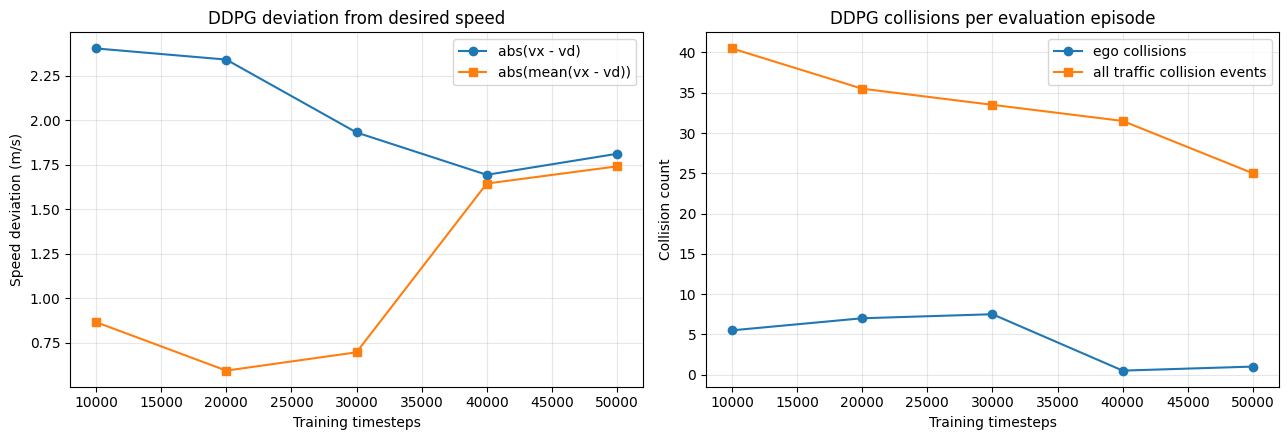

Saved DDPG plot to C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\ddpg_flat42_vmax24_ego_y_only_laneless_karalakou_metrics.png


In [20]:
if "ddpg_eval_history" not in globals() or ddpg_eval_history.empty:
    ddpg_eval_history = pd.read_csv(DDPG_HISTORY_PATH)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["mean_abs_speed_deviation"], marker="o", label="abs(vx - vd)")
axes[0].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["mean_signed_speed_deviation"].abs(), marker="s", label="abs(mean(vx - vd))")
axes[0].set_title("DDPG deviation from desired speed")
axes[0].set_xlabel("Training timesteps")
axes[0].set_ylabel("Speed deviation (m/s)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["ego_collisions"], marker="o", label="ego collisions")
axes[1].plot(ddpg_eval_history["timesteps"], ddpg_eval_history["total_collision_events"], marker="s", label="all traffic collision events")
axes[1].set_title("DDPG collisions per evaluation episode")
axes[1].set_xlabel("Training timesteps")
axes[1].set_ylabel("Collision count")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(DDPG_PLOT_PATH, dpi=160)
plt.show()
print("Saved DDPG plot to", DDPG_PLOT_PATH)

## DDPG Final Evaluation

In [21]:
ddpg_trained_model = DDPG.load(str(DDPG_MODEL_PATH), device=DEVICE)
ddpg_final_metrics = evaluate_policy_with_metrics(
    ddpg_trained_model,
    episodes=FINAL_EVAL_EPISODES,
    seed=SEED + 60_000,
    deterministic=True,
)
display(ddpg_final_metrics)
display(ddpg_final_metrics.drop(columns=["episode"]).mean().to_frame("mean"))

,episode,steps,return,mean_speed,mean_signed_speed_deviation,mean_abs_speed_deviation,ego_collisions,ego_collision_steps,total_collision_events
0,0,800,361.945165,18.550849,-1.449151,1.513007,0.0,0.0,27.0
1,1,800,288.047141,18.387822,-1.612178,1.723413,0.0,0.0,36.0
2,2,800,203.806794,18.284839,-1.715161,1.759809,2.0,4.0,28.0
3,3,800,299.599908,18.020792,-1.979208,2.099355,0.0,0.0,21.0
4,4,800,244.794570,18.747811,-1.252189,1.362727,3.0,10.0,38.0
5,5,800,333.328472,18.652872,-1.347128,1.848679,2.0,4.0,45.0
6,6,800,303.100170,18.582849,-1.417151,1.561045,0.0,0.0,35.0
7,7,800,274.774449,18.378247,-1.621753,1.678836,0.0,0.0,30.0
8,8,800,159.498021,18.439599,-1.560401,1.665217,7.0,48.0,50.0
9,9,800,395.479471,18.478004,-1.521996,1.810017,0.0,0.0,31.0


,mean
steps,800.000000
return,269.321400
mean_speed,18.413542
mean_signed_speed_deviation,-1.586458
mean_abs_speed_deviation,1.715912
ego_collisions,1.480000
ego_collision_steps,5.900000
total_collision_events,30.940000


## Render The Trained DDPG Policy

Set `RUN_DDPG_RENDER = True` when you want a live highway-env render window.

In [22]:
RUN_DDPG_RENDER = True
DDPG_RENDER_STEPS = 1_000

if RUN_DDPG_RENDER:
    ddpg_render_env = make_single_env(seed=SEED + 109_000, render_mode="human")
    obs, _ = ddpg_render_env.reset(seed=SEED + 109_000)
    for _ in range(DDPG_RENDER_STEPS):
        action, _ = ddpg_trained_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = ddpg_render_env.step(action)
        if terminated or truncated:
            obs, _ = ddpg_render_env.reset()
    ddpg_render_env.close()

KeyboardInterrupt: 

## DDPG-CBF Safety Shield

This section defines a non-differentiable 2D CBF-QP action shield. The policy proposes a raw physical acceleration action, the shield minimally modifies it, and the environment executes the filtered action. This is a shielded-env formulation: DDPG learns through the dynamics induced by the non-differentiable action shield.

In [23]:
try:
    from qpsolvers import solve_qp
    from scipy import sparse
except ImportError as exc:
    raise ImportError("Install CBF-QP dependencies first: !python -m pip install qpsolvers osqp") from exc

In [24]:
CBF_AX_BOUNDS = (-3.0, 3.0)
CBF_AY_BOUNDS = (-3.0, 3.0)
CBF_TARGET_PAIR_DY = 3.0
CBF_REFERENCE_EGO_WIDTH = float(ENV_CONFIG["ego_dimensions"][1])
CBF_REFERENCE_SOCIAL_WIDTH = float(ENV_CONFIG["vehicle_dimensions"][0][1])
CBF_EPS_SIDE = max(
    (CBF_TARGET_PAIR_DY - (CBF_REFERENCE_EGO_WIDTH + CBF_REFERENCE_SOCIAL_WIDTH) / np.sqrt(2.0)) / 4.0,
    0.0,
)
CBF_K0 = 8.0
CBF_K1 = 0.5
CBF_NEIGHBOR_RANGE = float(ENV_CONFIG["sensing_range"])
CBF_FILTER_REWARD_LAMBDA = 0.05


def inflated_ellipse_axes(length: float, width: float, eps_side: float = CBF_EPS_SIDE) -> tuple[float, float]:
    """Inflated ellipse semi-axes that cover a rectangular vehicle footprint."""
    a = float(length) / np.sqrt(2.0) + 2.0 * float(eps_side)
    b = float(width) / np.sqrt(2.0) + 2.0 * float(eps_side)
    return max(float(a), 1e-6), max(float(b), 1e-6)


def _wrap_angle(angle: float) -> float:
    return float((float(angle) + np.pi) % (2.0 * np.pi) - np.pi)


def ellipse_radius_along_line(a: float, b: float, delta: float) -> float:
    """Radius from ellipse center to boundary along a ray at angle delta from major axis."""
    cos_delta = np.cos(float(delta))
    sin_delta = np.sin(float(delta))
    denom = np.sqrt((float(b) * cos_delta) ** 2 + (float(a) * sin_delta) ** 2)
    return float(float(a) * float(b) / max(float(denom), 1e-9))


def pairwise_centerline_clearance(
    p: np.ndarray,
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: float = CBF_EPS_SIDE,
) -> tuple[float, float, float, float]:
    r = float(np.linalg.norm(p))
    if r < 1e-9:
        phi = 0.0
    else:
        phi = float(np.arctan2(float(p[1]), float(p[0])))

    a_ego, b_ego = inflated_ellipse_axes(ego["length"], ego["width"], eps_side)
    a_other, b_other = inflated_ellipse_axes(other["length"], other["width"], eps_side)
    l_ego = ellipse_radius_along_line(a_ego, b_ego, _wrap_angle(phi - float(ego.get("heading", 0.0))))
    l_other = ellipse_radius_along_line(a_other, b_other, _wrap_angle(phi - float(other.get("heading", 0.0))))
    required_distance = l_ego + l_other
    h = r - required_distance
    return float(h), float(r), float(l_ego), float(l_other)




def _wrapped_signed_dx(raw_dx: float, road_length: Optional[float] = None) -> float:
    """Shortest signed longitudinal distance on the ring road, in meters."""
    dx = float(raw_dx)
    if road_length is None:
        return dx
    length = float(road_length)
    if not np.isfinite(length) or length <= 0.0:
        return dx
    return float(((dx + 0.5 * length) % length) - 0.5 * length)


def pairwise_relative_state(ego: dict[str, float], other: dict[str, float]) -> tuple[float, float, float, float]:
    """Relative physical state: neighbor relative to ego, with wrapped ring-road dx."""
    if "signed_dx" in other:
        dx = float(other["signed_dx"])
    else:
        road_length = other.get("road_length", ego.get("road_length"))
        dx = _wrapped_signed_dx(float(other["x"]) - float(ego["x"]), road_length)
    dy = float(other["y"]) - float(ego["y"])
    dvx = float(other["vx"]) - float(ego["vx"])
    dvy = float(other["vy"]) - float(ego["vy"])
    return float(dx), float(dy), float(dvx), float(dvy)


def pairwise_cbf_geometry(
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: float = CBF_EPS_SIDE,
) -> tuple[float, float, float, float, float, float, float]:
    dx, dy, dvx, dvy = pairwise_relative_state(ego, other)
    h, center_distance, l_ego, l_other = pairwise_centerline_clearance(
        np.asarray([dx, dy], dtype=float),
        ego,
        other,
        eps_side,
    )
    required_distance = l_ego + l_other
    return float(h), dx, dy, dvx, dvy, float(center_distance), float(required_distance)


def centerline_barrier_derivatives(
    p: np.ndarray,
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: float = CBF_EPS_SIDE,
    fd_step: float = 1e-3,
) -> tuple[float, np.ndarray, np.ndarray, float, float, float]:
    p = np.asarray(p, dtype=float).reshape(2)

    def f(point: np.ndarray) -> tuple[float, float, float, float]:
        return pairwise_centerline_clearance(point, ego, other, eps_side)

    h0, center_distance, l_ego, l_other = f(p)
    e_x = np.asarray([fd_step, 0.0], dtype=float)
    e_y = np.asarray([0.0, fd_step], dtype=float)
    h_px = f(p + e_x)[0]
    h_mx = f(p - e_x)[0]
    h_py = f(p + e_y)[0]
    h_my = f(p - e_y)[0]
    grad = np.asarray([(h_px - h_mx) / (2.0 * fd_step), (h_py - h_my) / (2.0 * fd_step)], dtype=float)
    h_pp = f(p + e_x + e_y)[0]
    h_pm = f(p + e_x - e_y)[0]
    h_mp = f(p - e_x + e_y)[0]
    h_mm = f(p - e_x - e_y)[0]
    hessian = np.asarray(
        [
            [(h_px - 2.0 * h0 + h_mx) / (fd_step**2), (h_pp - h_pm - h_mp + h_mm) / (4.0 * fd_step**2)],
            [(h_pp - h_pm - h_mp + h_mm) / (4.0 * fd_step**2), (h_py - 2.0 * h0 + h_my) / (fd_step**2)],
        ],
        dtype=float,
    )
    return float(h0), grad, hessian, float(center_distance), float(l_ego), float(l_other)


def pairwise_hocbf_constraint(
    ego: dict[str, float],
    other: dict[str, float],
    eps_side: float = CBF_EPS_SIDE,
    k0: float = CBF_K0,
    k1: float = CBF_K1,
    other_acc: Optional[np.ndarray] = None,
) -> tuple[np.ndarray, float, float, float, float]:
    dx, dy, dvx, dvy = pairwise_relative_state(ego, other)
    p = np.asarray([dx, dy], dtype=float)
    v = np.asarray([dvx, dvy], dtype=float)
    a_j = np.zeros(2, dtype=float) if other_acc is None else np.asarray(other_acc, dtype=float).reshape(-1)[:2]
    h, grad, hessian, center_distance, l_ego, l_other = centerline_barrier_derivatives(p, ego, other, eps_side)
    h_dot = float(grad @ v)
    A = np.asarray(grad, dtype=float)
    b = float(v.T @ hessian @ v + grad @ a_j + float(k1) * h_dot + float(k0) * h)
    return A, b, float(h), float(center_distance), float(l_ego + l_other)


def cbf_filter_2d(
    a_rl,
    ego: dict[str, float],
    neighbors: list[dict[str, float]],
    road_width: float,
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
    eps_side: float = CBF_EPS_SIDE,
    k0: float = CBF_K0,
    k1: float = CBF_K1,
) -> tuple[np.ndarray, dict[str, Any]]:
    a_rl = np.asarray(a_rl, dtype=float).reshape(-1)
    if a_rl.size < 2:
        raise ValueError("a_rl must contain [ax, ay].")
    a_rl = a_rl[:2]

    P = sparse.csc_matrix(2.0 * np.eye(2, dtype=float))
    q = -2.0 * a_rl
    G_rows: list[np.ndarray] = []
    h_rows: list[float] = []
    min_h = np.inf
    min_center_distance = np.inf
    min_required_distance = np.inf
    neighbor_constraints = 0

    for neighbor in neighbors:
        other_acc = np.asarray([float(neighbor.get("ax", 0.0)), float(neighbor.get("ay", 0.0))], dtype=float)
        A, b, h_ij, center_distance, required_distance = pairwise_hocbf_constraint(
            ego,
            neighbor,
            eps_side=eps_side,
            k0=k0,
            k1=k1,
            other_acc=other_acc,
        )
        min_h = min(min_h, h_ij)
        min_center_distance = min(min_center_distance, center_distance)
        min_required_distance = min(min_required_distance, required_distance)
        G_rows.append(A)
        h_rows.append(b)
        neighbor_constraints += 1

    ego_y = float(ego["y"])
    ego_vy = float(ego["vy"])
    ego_half_width = 0.5 * float(ego["width"])
    h_left = ego_y - ego_half_width
    h_right = float(road_width) - ego_half_width - ego_y

    G_rows.append(np.asarray([0.0, -1.0], dtype=float))
    h_rows.append(float(k1 * ego_vy + k0 * h_left))
    G_rows.append(np.asarray([0.0, 1.0], dtype=float))
    h_rows.append(float(-k1 * ego_vy + k0 * h_right))

    G = sparse.csc_matrix(np.asarray(G_rows, dtype=float))
    h_vec = np.asarray(h_rows, dtype=float)
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)

    qp_error = ""
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=r"OSQP exited.*")
            solution = solve_qp(P, q, G=G, h=h_vec, lb=lb, ub=ub, solver="osqp", verbose=False)
    except Exception as exc:
        solution = None
        qp_error = repr(exc)

    qp_success = solution is not None and bool(np.all(np.isfinite(solution)))
    if qp_success:
        a_safe = np.clip(np.asarray(solution, dtype=float), lb, ub)
    else:
        a_safe = np.asarray([float(ax_bounds[0]), 0.0], dtype=float)

    correction_norm = float(np.linalg.norm(a_safe - a_rl))
    if not np.isfinite(min_h):
        min_h = np.nan
    if not np.isfinite(min_center_distance):
        min_center_distance = np.nan
    if not np.isfinite(min_required_distance):
        min_required_distance = np.nan

    info = {
        "a_safe": a_safe.astype(np.float32),
        "correction_norm": correction_norm,
        "min_h": float(min_h),
        "min_center_distance": float(min_center_distance),
        "min_required_distance": float(min_required_distance),
        "eps_side": float(eps_side),
        "qp_success": bool(qp_success),
        "fallback_used": bool(not qp_success),
        "qp_error": qp_error,
        "num_neighbor_constraints": int(neighbor_constraints),
        "left_boundary_h": float(h_left),
        "right_boundary_h": float(h_right),
        "min_boundary_h": float(min(h_left, h_right)),
    }
    return a_safe.astype(np.float32), info

In [25]:
def _lane_free_base(env: gym.Env):
    return env.unwrapped


def _physical_to_normalized_action(env: gym.Env, a_physical: np.ndarray) -> np.ndarray:
    base = _lane_free_base(env)
    bounds = base.config["bounds"]
    physical_bounds = [
        (float(bounds["ax_min"]), float(bounds["ax_max"])),
        (float(bounds["ay_min"]), float(bounds["ay_max"])),
    ]
    normalized = np.zeros(2, dtype=np.float32)
    for index, (value, (low, high)) in enumerate(zip(np.asarray(a_physical, dtype=float), physical_bounds)):
        value = float(np.clip(value, low, high))
        if low < 0.0 < high:
            scale = high if value >= 0.0 else abs(low)
            normalized[index] = value / max(scale, 1e-6)
        else:
            normalized[index] = float(2.0 * (value - low) / max(high - low, 1e-6) - 1.0)
    return np.clip(normalized, -1.0, 1.0)


def get_ego_state(env: gym.Env) -> dict[str, float]:
    base = _lane_free_base(env)
    ego = base.vehicle
    return {
        "x": float(ego.position[0]),
        "y": float(ego.position[1]),
        "vx": float(ego.vx),
        "vy": float(ego.vy),
        "heading": float(ego.heading),
        "length": float(ego.length),
        "width": float(ego.width),
        "road_length": float(base.config["road_length"]),
    }


def get_neighbor_states(env: gym.Env, neighbor_range: Optional[float] = None) -> list[dict[str, float]]:
    base = _lane_free_base(env)
    ego = base.vehicle
    max_range = float(base.config["sensing_range"] if neighbor_range is None else neighbor_range)
    neighbors: list[dict[str, float]] = []

    for index, vehicle in enumerate(base.road.vehicles):
        if vehicle is ego:
            continue
        dx = float(base._signed_distance(ego.position[0], vehicle.position[0]))
        dy = float(vehicle.position[1] - ego.position[1])
        distance = float(np.sqrt(dx * dx + dy * dy))
        if distance > max_range:
            continue

        ax = ay = 0.0
        if len(base._last_accelerations) > index:
            ax = float(base._last_accelerations[index, 0])
            ay = float(base._last_accelerations[index, 1])

        neighbors.append(
            {
                "x": float(ego.position[0] + dx),
                "y": float(vehicle.position[1]),
                "vx": float(vehicle.vx),
                "vy": float(vehicle.vy),
                "heading": float(vehicle.heading),
                "ax": ax,
                "ay": ay,
                "length": float(vehicle.length),
                "width": float(vehicle.width),
                "distance": distance,
                "signed_dx": dx,
            }
        )

    return sorted(neighbors, key=lambda item: item["distance"])

In [26]:
class SafetyFilteredAccelerationWrapper(gym.Wrapper):
    """Non-differentiable CBF-QP action shield over physical acceleration actions."""

    def __init__(
        self,
        env: gym.Env,
        lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
        neighbor_range: float = CBF_NEIGHBOR_RANGE,
        ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
        ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
        eps_side: float = CBF_EPS_SIDE,
        k0: float = CBF_K0,
        k1: float = CBF_K1,
    ) -> None:
        super().__init__(env)
        self.lambda_filter = float(lambda_filter)
        self.neighbor_range = float(neighbor_range)
        self.ax_bounds = ax_bounds
        self.ay_bounds = ay_bounds
        self.eps_side = float(eps_side)
        self.k0 = float(k0)
        self.k1 = float(k1)
        self.action_space = gym.spaces.Box(
            low=np.asarray([ax_bounds[0], ay_bounds[0]], dtype=np.float32),
            high=np.asarray([ax_bounds[1], ay_bounds[1]], dtype=np.float32),
            dtype=np.float32,
        )

    def get_ego_state(self) -> dict[str, float]:
        return get_ego_state(self)

    def get_neighbor_states(self) -> list[dict[str, float]]:
        return get_neighbor_states(self, neighbor_range=self.neighbor_range)

    def step(self, action):
        a_rl = np.asarray(action, dtype=np.float32).reshape(-1)[:2]
        ego = get_ego_state(self)
        neighbors = get_neighbor_states(self, neighbor_range=self.neighbor_range)
        road_width = float(_lane_free_base(self).config["road_width"])
        a_safe, filter_info = cbf_filter_2d(
            a_rl,
            ego,
            neighbors,
            road_width,
            ax_bounds=self.ax_bounds,
            ay_bounds=self.ay_bounds,
            eps_side=self.eps_side,
            k0=self.k0,
            k1=self.k1,
        )
        normalized_action = _physical_to_normalized_action(self, a_safe)
        obs, reward, terminated, truncated, info = self.env.step(normalized_action)
        correction_norm = float(filter_info["correction_norm"])
        reward = float(reward) - self.lambda_filter * correction_norm**2

        info = dict(info)
        info.update(
            {
                "cbf_a_rl_x": float(a_rl[0]),
                "cbf_a_rl_y": float(a_rl[1]),
                "cbf_a_safe_x": float(a_safe[0]),
                "cbf_a_safe_y": float(a_safe[1]),
                "cbf_correction_norm": correction_norm,
                "cbf_intervened": bool(correction_norm > 1e-6),
                "cbf_min_h": float(filter_info["min_h"]),
                "cbf_min_center_distance": float(filter_info["min_center_distance"]),
                "cbf_min_required_distance": float(filter_info["min_required_distance"]),
                "cbf_eps_side": float(filter_info["eps_side"]),
                "cbf_qp_success": bool(filter_info["qp_success"]),
                "cbf_fallback_used": bool(filter_info.get("fallback_used", not filter_info["qp_success"])),
                "cbf_qp_error": str(filter_info["qp_error"]),
                "cbf_num_neighbor_constraints": int(filter_info["num_neighbor_constraints"]),
                "cbf_min_boundary_h": float(filter_info["min_boundary_h"]),
                "cbf_left_boundary_h": float(filter_info["left_boundary_h"]),
                "cbf_right_boundary_h": float(filter_info["right_boundary_h"]),
                "cbf_filter_reward_penalty": float(self.lambda_filter * correction_norm**2),
            }
        )
        return obs, reward, terminated, truncated, info


def make_cbf_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: float = CBF_EPS_SIDE,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    env = SafetyFilteredAccelerationWrapper(env, lambda_filter=lambda_filter, eps_side=eps_side)
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_cbf_training_env(
    seed: int = SEED,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: float = CBF_EPS_SIDE,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = False,
):
    def _single_env(env_seed: int) -> gym.Env:
        return make_cbf_single_env(
            seed=env_seed,
            render_mode=None,
            lambda_filter=lambda_filter,
            eps_side=eps_side,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )

In [27]:
# Tuned DDPG-CBF shield overrides, no slack
# Run this cell after the base CBF definitions and before DDPG-CBF training/evaluation.
# It intentionally overrides cbf_filter_2d, SafetyFilteredAccelerationWrapper, and make_cbf_*_env.

# Keep this override self-contained in case the earlier dependency cell was skipped.
try:
    from qpsolvers import solve_qp
    from scipy import sparse
except ImportError as exc:
    raise ImportError("Install CBF-QP dependencies first: !python -m pip install qpsolvers osqp") from exc

CBF_AX_BOUNDS = (-3.0, 3.0)
CBF_AY_BOUNDS = (-3.0, 3.0)
CBF_K0 = 2.0
CBF_K1 = 4.0
CBF_MAX_NEIGHBOR_CONSTRAINTS = 12
CBF_QP_SOLVER = "osqp"


def _cbf_emergency_fallback_action(
    a_rl: np.ndarray,
    ego: dict[str, float],
    neighbors: list[dict[str, float]],
    road_width: float,
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
    eps_side: float = CBF_EPS_SIDE,
) -> np.ndarray:
    """Rare solver-failure fallback. Prefer evasive direction over blind straight braking."""
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)
    action = np.clip(np.asarray(a_rl, dtype=float).reshape(-1)[:2], lb, ub)

    scored_neighbors: list[tuple[float, dict[str, float], float, float, float, float]] = []
    for neighbor in neighbors:
        h, dx, dy, dvx, dvy, _, _ = pairwise_cbf_geometry(ego, neighbor, eps_side=eps_side)
        scored_neighbors.append((float(h), neighbor, float(dx), float(dy), float(dvx), float(dvy)))

    if scored_neighbors:
        h, _, dx, dy, dvx, dvy = min(scored_neighbors, key=lambda item: item[0])
        p = np.asarray([dx, dy], dtype=float)
        v = np.asarray([dvx, dvy], dtype=float)
        closing_speed = float(-(p @ v) / max(float(np.linalg.norm(p)), 1e-6))

        if h < 2.0 and dx > 0.0 and closing_speed > 0.0:
            action[0] = min(action[0], float(ax_bounds[0]))
        if h < 1.0 and abs(dy) > 1e-6:
            action[1] = float(ay_bounds[0] if dy > 0.0 else ay_bounds[1])

    ego_y = float(ego["y"])
    ego_half_width = 0.5 * float(ego["width"])
    if ego_y - ego_half_width < 0.5:
        action[1] = max(action[1], 0.0)
    if float(road_width) - ego_half_width - ego_y < 0.5:
        action[1] = min(action[1], 0.0)

    return np.clip(action, lb, ub).astype(np.float32)


def _least_violating_bounded_action(
    a_rl: np.ndarray,
    constraint_rows: list[np.ndarray],
    constraint_bounds: list[float],
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
) -> np.ndarray:
    """Fallback for infeasible hard-QP states: choose the bounded action with smallest violation."""
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)
    target = np.clip(np.asarray(a_rl, dtype=float).reshape(-1)[:2], lb, ub)
    rows = np.asarray(constraint_rows, dtype=float)
    bounds = np.asarray(constraint_bounds, dtype=float)

    ax_grid = np.unique(np.r_[np.linspace(lb[0], ub[0], 25), target[0], lb[0], ub[0]])
    ay_grid = np.unique(np.r_[np.linspace(lb[1], ub[1], 25), target[1], lb[1], ub[1]])

    best_action = target.copy()
    best_score: tuple[float, float, float] | None = None
    for ax in ax_grid:
        for ay in ay_grid:
            candidate = np.asarray([ax, ay], dtype=float)
            violations = rows @ candidate - bounds
            positive = np.maximum(violations, 0.0)
            max_violation = float(np.max(positive)) if positive.size else 0.0
            total_violation = float(np.sum(positive**2))
            correction = float(np.sum((candidate - target) ** 2))
            score = (max_violation, total_violation, correction)
            if best_score is None or score < best_score:
                best_score = score
                best_action = candidate

    return np.clip(best_action, lb, ub).astype(np.float32)


def cbf_filter_2d(
    a_rl,
    ego: dict[str, float],
    neighbors: list[dict[str, float]],
    road_width: float,
    ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
    ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
    eps_side: float = CBF_EPS_SIDE,
    k0: float = CBF_K0,
    k1: float = CBF_K1,
    max_neighbor_constraints: Optional[int] = CBF_MAX_NEIGHBOR_CONSTRAINTS,
) -> tuple[np.ndarray, dict[str, Any]]:
    """Hard HOCBF-QP filter over physical acceleration actions using tuned gains."""
    a_rl = np.asarray(a_rl, dtype=float).reshape(-1)
    if a_rl.size < 2:
        raise ValueError("a_rl must contain [ax, ay].")
    a_rl = a_rl[:2]

    if max_neighbor_constraints is not None:
        neighbors = list(neighbors)[: int(max_neighbor_constraints)]

    constraint_rows: list[np.ndarray] = []
    constraint_bounds: list[float] = []
    min_h = np.inf
    min_center_distance = np.inf
    min_required_distance = np.inf
    neighbor_constraints = 0

    for neighbor in neighbors:
        other_acc = np.asarray([float(neighbor.get("ax", 0.0)), float(neighbor.get("ay", 0.0))], dtype=float)
        A, b, h_ij, center_distance, required_distance = pairwise_hocbf_constraint(
            ego,
            neighbor,
            eps_side=eps_side,
            k0=k0,
            k1=k1,
            other_acc=other_acc,
        )
        constraint_rows.append(np.asarray(A, dtype=float))
        constraint_bounds.append(float(b))
        min_h = min(min_h, float(h_ij))
        min_center_distance = min(min_center_distance, float(center_distance))
        min_required_distance = min(min_required_distance, float(required_distance))
        neighbor_constraints += 1

    ego_y = float(ego["y"])
    ego_vy = float(ego["vy"])
    ego_half_width = 0.5 * float(ego["width"])
    h_left = ego_y - ego_half_width
    h_right = float(road_width) - ego_half_width - ego_y

    # h_left = y - b:    ay + k1*vy + k0*h_left >= 0 -> -ay <= k1*vy + k0*h_left
    # h_right = W-b-y: -ay - k1*vy + k0*h_right >= 0 ->  ay <= -k1*vy + k0*h_right
    constraint_rows.append(np.asarray([0.0, -1.0], dtype=float))
    constraint_bounds.append(float(k1 * ego_vy + k0 * h_left))
    constraint_rows.append(np.asarray([0.0, 1.0], dtype=float))
    constraint_bounds.append(float(-k1 * ego_vy + k0 * h_right))

    P = sparse.csc_matrix(2.0 * np.eye(2, dtype=float))
    q = -2.0 * a_rl
    G = sparse.csc_matrix(np.asarray(constraint_rows, dtype=float))
    h_vec = np.asarray(constraint_bounds, dtype=float)
    lb = np.asarray([float(ax_bounds[0]), float(ay_bounds[0])], dtype=float)
    ub = np.asarray([float(ax_bounds[1]), float(ay_bounds[1])], dtype=float)

    qp_error = ""
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=r"OSQP exited.*")
            solution = solve_qp(P, q, G=G, h=h_vec, lb=lb, ub=ub, solver=CBF_QP_SOLVER, verbose=False)
    except Exception as exc:
        solution = None
        qp_error = repr(exc)

    qp_success = solution is not None and bool(np.all(np.isfinite(solution)))
    if qp_success:
        a_safe = np.clip(np.asarray(solution, dtype=float).reshape(-1)[:2], lb, ub)
    else:
        a_safe = _least_violating_bounded_action(a_rl, constraint_rows, constraint_bounds, ax_bounds, ay_bounds)
        emergency_action = _cbf_emergency_fallback_action(a_rl, ego, neighbors, road_width, ax_bounds, ay_bounds, eps_side)
        current_violation = max(
            float(np.max(np.maximum(np.asarray([row @ a_safe - b for row, b in zip(constraint_rows, constraint_bounds)]), 0.0))),
            0.0,
        )
        emergency_violation = max(
            float(np.max(np.maximum(np.asarray([row @ emergency_action - b for row, b in zip(constraint_rows, constraint_bounds)]), 0.0))),
            0.0,
        )
        if emergency_violation + 1e-9 < current_violation:
            a_safe = emergency_action

    rl_constraint_values = np.asarray([row @ a_rl - b for row, b in zip(constraint_rows, constraint_bounds)], dtype=float)
    safe_constraint_values = np.asarray([row @ a_safe - b for row, b in zip(constraint_rows, constraint_bounds)], dtype=float)

    correction_norm = float(np.linalg.norm(a_safe - a_rl))
    if not np.isfinite(min_h):
        min_h = np.nan
    if not np.isfinite(min_center_distance):
        min_center_distance = np.nan
    if not np.isfinite(min_required_distance):
        min_required_distance = np.nan

    info = {
        "a_safe": a_safe.astype(np.float32),
        "correction_norm": correction_norm,
        "max_constraint_violation_rl": float(np.max(rl_constraint_values)) if len(rl_constraint_values) else 0.0,
        "max_constraint_violation_safe": float(np.max(safe_constraint_values)) if len(safe_constraint_values) else 0.0,
        "min_h": float(min_h),
        "min_center_distance": float(min_center_distance),
        "min_required_distance": float(min_required_distance),
        "eps_side": float(eps_side),
        "k0": float(k0),
        "k1": float(k1),
        "qp_success": bool(qp_success),
        "fallback_used": bool(not qp_success),
        "qp_error": qp_error,
        "num_neighbor_constraints": int(neighbor_constraints),
        "left_boundary_h": float(h_left),
        "right_boundary_h": float(h_right),
        "min_boundary_h": float(min(h_left, h_right)),
    }
    return a_safe.astype(np.float32), info


class SafetyFilteredAccelerationWrapper(gym.Wrapper):
    """Tuned no-slack DDPG-CBF action shield over physical acceleration actions."""

    def __init__(
        self,
        env: gym.Env,
        lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
        neighbor_range: float = CBF_NEIGHBOR_RANGE,
        ax_bounds: tuple[float, float] = CBF_AX_BOUNDS,
        ay_bounds: tuple[float, float] = CBF_AY_BOUNDS,
        eps_side: float = CBF_EPS_SIDE,
        k0: float = CBF_K0,
        k1: float = CBF_K1,
        max_neighbor_constraints: Optional[int] = CBF_MAX_NEIGHBOR_CONSTRAINTS,
    ) -> None:
        super().__init__(env)
        self.lambda_filter = float(lambda_filter)
        self.neighbor_range = float(neighbor_range)
        self.ax_bounds = ax_bounds
        self.ay_bounds = ay_bounds
        self.eps_side = float(eps_side)
        self.k0 = float(k0)
        self.k1 = float(k1)
        self.max_neighbor_constraints = max_neighbor_constraints
        self.action_space = gym.spaces.Box(
            low=np.asarray([ax_bounds[0], ay_bounds[0]], dtype=np.float32),
            high=np.asarray([ax_bounds[1], ay_bounds[1]], dtype=np.float32),
            dtype=np.float32,
        )

    def get_ego_state(self) -> dict[str, float]:
        return get_ego_state(self)

    def get_neighbor_states(self) -> list[dict[str, float]]:
        return get_neighbor_states(self, neighbor_range=self.neighbor_range)

    def step(self, action):
        a_rl = np.asarray(action, dtype=np.float32).reshape(-1)[:2]
        ego = get_ego_state(self)
        neighbors = get_neighbor_states(self, neighbor_range=self.neighbor_range)
        road_width = float(_lane_free_base(self).config["road_width"])
        a_safe, filter_info = cbf_filter_2d(
            a_rl,
            ego,
            neighbors,
            road_width,
            ax_bounds=self.ax_bounds,
            ay_bounds=self.ay_bounds,
            eps_side=self.eps_side,
            k0=self.k0,
            k1=self.k1,
            max_neighbor_constraints=self.max_neighbor_constraints,
        )
        normalized_action = _physical_to_normalized_action(self, a_safe)
        obs, reward, terminated, truncated, info = self.env.step(normalized_action)
        correction_norm = float(filter_info["correction_norm"])
        correction_penalty = self.lambda_filter * correction_norm**2
        reward = float(reward) - correction_penalty

        info = dict(info)
        info.update(
            {
                "cbf_a_rl_x": float(a_rl[0]),
                "cbf_a_rl_y": float(a_rl[1]),
                "cbf_a_safe_x": float(a_safe[0]),
                "cbf_a_safe_y": float(a_safe[1]),
                "cbf_correction_norm": correction_norm,
                "cbf_intervened": bool(correction_norm > 1e-6),
                "cbf_max_constraint_violation_rl": float(filter_info["max_constraint_violation_rl"]),
                "cbf_max_constraint_violation_safe": float(filter_info["max_constraint_violation_safe"]),
                "cbf_min_h": float(filter_info["min_h"]),
                "cbf_min_center_distance": float(filter_info["min_center_distance"]),
                "cbf_min_required_distance": float(filter_info["min_required_distance"]),
                "cbf_eps_side": float(filter_info["eps_side"]),
                "cbf_k0": float(filter_info["k0"]),
                "cbf_k1": float(filter_info["k1"]),
                "cbf_qp_success": bool(filter_info["qp_success"]),
                "cbf_fallback_used": bool(filter_info.get("fallback_used", not filter_info["qp_success"])),
                "cbf_qp_error": str(filter_info["qp_error"]),
                "cbf_num_neighbor_constraints": int(filter_info["num_neighbor_constraints"]),
                "cbf_min_boundary_h": float(filter_info["min_boundary_h"]),
                "cbf_left_boundary_h": float(filter_info["left_boundary_h"]),
                "cbf_right_boundary_h": float(filter_info["right_boundary_h"]),
                "cbf_filter_reward_penalty": float(correction_penalty),
            }
        )
        return obs, reward, terminated, truncated, info


def make_cbf_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: float = CBF_EPS_SIDE,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    env = SafetyFilteredAccelerationWrapper(env, lambda_filter=lambda_filter, eps_side=eps_side)
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_cbf_training_env(
    seed: int = SEED,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: float = CBF_EPS_SIDE,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = False,
):
    def _single_env(env_seed: int) -> gym.Env:
        return make_cbf_single_env(
            seed=env_seed,
            render_mode=None,
            lambda_filter=lambda_filter,
            eps_side=eps_side,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )


print(
    "Tuned no-slack CBF override active:",
    {
        "k0": CBF_K0,
        "k1": CBF_K1,
        "correction_reward_lambda": CBF_FILTER_REWARD_LAMBDA,
        "max_neighbor_constraints": CBF_MAX_NEIGHBOR_CONSTRAINTS,
    },
)


Tuned no-slack CBF override active: {'k0': 2.0, 'k1': 4.0, 'correction_reward_lambda': 0.05, 'max_neighbor_constraints': 12}


## DDPG-CBF Evaluation Helpers

These metrics evaluate a policy through the shielded environment and log intervention behavior in addition to reward, speed tracking, and collisions.

In [28]:
def evaluate_cbf_policy_with_metrics(
    model: Any,
    episodes: int = EVAL_EPISODES,
    seed: int = SEED + 40_000,
    deterministic: bool = True,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
) -> pd.DataFrame:
    rows: list[dict[str, float]] = []
    for episode in range(episodes):
        env = make_cbf_single_env(
            seed=seed + episode,
            lambda_filter=lambda_filter,
            env_config=env_config,
            reward_config=reward_config,
        )
        configure_paper_evaluation_env(env, steps=PAPER_EVAL_STEPS)
        obs, _ = env.reset(seed=seed + episode)
        done = False
        step_count = 0
        rewards = []
        signed_deviations = []
        abs_deviations = []
        speeds = []
        corrections = []
        interventions = []
        qp_successes = []
        min_h_values = []
        ego_collisions = 0
        ego_collision_steps = 0
        all_collision_events = 0

        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            base = env.unwrapped
            desired = float(base.vehicle.desired_speed)
            speed = float(base.vehicle.vx)
            deviation = speed - desired

            rewards.append(float(reward))
            signed_deviations.append(deviation)
            abs_deviations.append(abs(deviation))
            speeds.append(speed)
            corrections.append(float(info.get("cbf_correction_norm", 0.0)))
            interventions.append(float(info.get("cbf_intervened", False)))
            qp_successes.append(float(info.get("cbf_qp_success", True)))
            min_h_values.append(float(info.get("cbf_min_h", np.nan)))
            all_collision_events += int(info.get("collisions", 0))
            ego_collisions += int(info.get("ego_collision_events", 0))
            if bool(info.get("ego_collision", False)):
                ego_collision_steps += 1

            step_count += 1
            done = bool(terminated or truncated)

        rows.append(
            {
                "episode": episode,
                "steps": step_count,
                "return": float(np.sum(rewards)),
                "mean_speed": float(np.mean(speeds)) if speeds else 0.0,
                "mean_signed_speed_deviation": float(np.mean(signed_deviations)) if signed_deviations else 0.0,
                "mean_abs_speed_deviation": float(np.mean(abs_deviations)) if abs_deviations else 0.0,
                "ego_collisions": float(ego_collisions),
                "ego_collision_steps": float(ego_collision_steps),
                "total_collision_events": float(all_collision_events),
                "mean_correction_norm": float(np.mean(corrections)) if corrections else 0.0,
                "max_correction_norm": float(np.max(corrections)) if corrections else 0.0,
                "intervention_rate": float(np.mean(interventions)) if interventions else 0.0,
                "qp_failure_rate": float(1.0 - np.mean(qp_successes)) if qp_successes else 0.0,
                "min_h": float(np.nanmin(min_h_values)) if min_h_values and not np.all(np.isnan(min_h_values)) else np.nan,
            }
        )
        env.close()
    return pd.DataFrame(rows)


class CBFEvalMetricsCallback(BaseCallback):
    def __init__(self, eval_freq: int, n_eval_episodes: int, seed: int, lambda_filter: float, verbose: int = 1) -> None:
        super().__init__(verbose=verbose)
        self.eval_freq = int(eval_freq)
        self.n_eval_episodes = int(n_eval_episodes)
        self.seed = int(seed)
        self.lambda_filter = float(lambda_filter)
        self.records: list[dict[str, float]] = []
        self._last_eval_step = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_eval_step < self.eval_freq:
            return True
        self._last_eval_step = self.num_timesteps
        metrics = evaluate_cbf_policy_with_metrics(
            self.model,
            episodes=self.n_eval_episodes,
            seed=self.seed + self.num_timesteps,
            deterministic=True,
            lambda_filter=self.lambda_filter,
        )
        row = {
            "timesteps": float(self.num_timesteps),
            "return": float(metrics["return"].mean()),
            "mean_abs_speed_deviation": float(metrics["mean_abs_speed_deviation"].mean()),
            "ego_collisions": float(metrics["ego_collisions"].mean()),
            "total_collision_events": float(metrics["total_collision_events"].mean()),
            "mean_correction_norm": float(metrics["mean_correction_norm"].mean()),
            "intervention_rate": float(metrics["intervention_rate"].mean()),
            "qp_failure_rate": float(metrics["qp_failure_rate"].mean()),
            "min_h": float(metrics["min_h"].min()),
        }
        self.records.append(row)
        if self.verbose:
            print(
                f"steps={self.num_timesteps:,} | "
                f"abs dev={row['mean_abs_speed_deviation']:.3f} m/s | "
                f"intervention={row['intervention_rate']:.2%} | "
                f"qp failures={row['qp_failure_rate']:.2%} | "
                f"ego collisions={row['ego_collisions']:.2f}"
            )
        return True

## Train DDPG-CBF

Train DDPG inside the shielded environment. The policy observes the same flat 42D legacy vehicle-table state as the baseline DDPG and outputs raw physical acceleration actions; the non-differentiable CBF-QP shield filters them before execution. This quick CBF run uses `DDPG_CBF_TOTAL_TIMESTEPS = 50_000`, separate from the non-CBF baseline budget `DDPG_TOTAL_TIMESTEPS`.

In [29]:
ddpg_cbf_train_env = make_cbf_training_env(
    seed=SEED,
    lambda_filter=CBF_FILTER_REWARD_LAMBDA,
    n_envs=DDPG_CBF_NUM_ENVS,
    use_subproc=DDPG_USE_SUBPROC_VEC_ENV,
)
ddpg_cbf_n_envs = int(getattr(ddpg_cbf_train_env, "num_envs", 1))
n_actions = ddpg_cbf_train_env.action_space.shape[-1]
ddpg_cbf_action_noise = make_ou_action_noise(n_actions, n_envs=ddpg_cbf_n_envs)
ddpg_cbf_eval_callback = CBFEvalMetricsCallback(
    eval_freq=TRAIN_EVAL_EVERY,
    n_eval_episodes=TRAIN_EVAL_EPISODES,
    seed=SEED + 70_000,
    lambda_filter=CBF_FILTER_REWARD_LAMBDA,
)
print(f"DDPG-CBF training envs: {ddpg_cbf_n_envs} | subproc requested={DDPG_USE_SUBPROC_VEC_ENV} | eval every {TRAIN_EVAL_EVERY:,} steps x {TRAIN_EVAL_EPISODES} episodes")

ddpg_cbf_model = DDPG(
    "MlpPolicy",
    ddpg_cbf_train_env,
    learning_rate=DDPG_LEARNING_RATE,
    buffer_size=DDPG_REPLAY_MEMORY,
    learning_starts=DDPG_LEARNING_STARTS,
    batch_size=DDPG_BATCH_SIZE,
    tau=DDPG_TAU,
    gamma=DDPG_GAMMA,
    train_freq=(1, "step"),
    gradient_steps=1,
    action_noise=ddpg_cbf_action_noise,
    policy_kwargs={"net_arch": [256, 128]},
    tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
    verbose=1,
    seed=SEED,
    device=DEVICE,
)

start_time = time.time()
ddpg_cbf_model.learn(total_timesteps=DDPG_CBF_TOTAL_TIMESTEPS, callback=ddpg_cbf_eval_callback, progress_bar=False)
ddpg_cbf_elapsed = time.time() - start_time

ddpg_cbf_model.save(str(DDPG_CBF_MODEL_PATH))
ddpg_cbf_train_env.close()

ddpg_cbf_eval_history = pd.DataFrame(ddpg_cbf_eval_callback.records)
ddpg_cbf_eval_history.to_csv(DDPG_CBF_HISTORY_PATH, index=False)
print(f"Saved DDPG-CBF model to {DDPG_CBF_MODEL_PATH}")
print(f"Saved DDPG-CBF eval history to {DDPG_CBF_HISTORY_PATH}")
print(f"DDPG-CBF training time: {ddpg_cbf_elapsed / 60:.1f} min")
display(ddpg_cbf_eval_history)

DDPG-CBF training envs: 4 | subproc requested=True | eval every 10,000 steps x 2 episodes
Using cuda device
Logging to C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\tensorboard\DDPG_66


C:\Users\aha173\AppData\Local\Temp\ipykernel_13192\3751744265.py:89: RuntimeWarning: SubprocVecEnv failed (EOFError()); falling back to DummyVecEnv. For real parallelism on Windows, run from an importable .py script if notebook subprocesses are blocked.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 800      |
|    ep_rew_mean     | 125      |
| time/              |          |
|    episodes        | 4        |
|    fps             | 106      |
|    time_elapsed    | 30       |
|    total_timesteps | 3200     |
| train/             |          |
|    actor_loss      | -0.347   |
|    critic_loss     | 0.0227   |
|    learning_rate   | 0.001    |
|    n_updates       | 549      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 700      |
|    ep_rew_mean     | 152      |
| time/              |          |
|    episodes        | 8        |
|    fps             | 102      |
|    time_elapsed    | 62       |
|    total_timesteps | 6400     |
| train/             |          |
|    actor_loss      | -0.584   |
|    critic_loss     | 0.00995  |
|    learning_rate   | 0.001    |
|    n_updates       | 1349     |
--------------

,timesteps,return,mean_abs_speed_deviation,ego_collisions,total_collision_events,mean_correction_norm,intervention_rate,qp_failure_rate,min_h
0,10000.0,290.160672,1.826027,0.5,31.5,0.092328,0.287500,0.013750,-1.201976
1,20000.0,230.628314,2.005435,0.0,19.5,0.284397,0.632500,0.131250,-0.877762
2,30000.0,233.041826,1.634186,0.5,31.0,0.345381,0.631875,0.104375,-0.955451
3,40000.0,248.768040,1.918047,1.0,23.5,0.275631,0.522500,0.122500,-0.882696
4,50000.0,293.862541,1.213499,0.0,38.0,0.142941,0.554375,0.000000,-0.430157


## Plot DDPG-CBF Training Results

In [ ]:
if "ddpg_cbf_eval_history" not in globals() or ddpg_cbf_eval_history.empty:
    ddpg_cbf_eval_history = pd.read_csv(DDPG_CBF_HISTORY_PATH)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["mean_abs_speed_deviation"], marker="o", label="abs(vx - vd)")
axes[0, 0].set_title("DDPG-CBF deviation from desired speed")
axes[0, 0].set_xlabel("Training timesteps")
axes[0, 0].set_ylabel("Speed deviation (m/s)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["ego_collisions"], marker="o", label="ego collisions")
axes[0, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["total_collision_events"], marker="s", label="all traffic collision events")
axes[0, 1].set_title("DDPG-CBF collisions per evaluation episode")
axes[0, 1].set_xlabel("Training timesteps")
axes[0, 1].set_ylabel("Collision count")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["mean_correction_norm"], marker="o", label="mean correction")
axes[1, 0].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["intervention_rate"], marker="s", label="intervention rate")
axes[1, 0].set_title("CBF shield interventions")
axes[1, 0].set_xlabel("Training timesteps")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["qp_failure_rate"], marker="o", label="QP failure rate")
axes[1, 1].plot(ddpg_cbf_eval_history["timesteps"], ddpg_cbf_eval_history["min_h"], marker="s", label="min h")
axes[1, 1].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[1, 1].set_title("CBF feasibility and safety margin")
axes[1, 1].set_xlabel("Training timesteps")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

fig.tight_layout()
fig.savefig(DDPG_CBF_PLOT_PATH, dpi=160)
plt.show()
print("Saved DDPG-CBF plot to", DDPG_CBF_PLOT_PATH)

## DDPG-CBF Final Evaluation

In [30]:
ddpg_cbf_trained_model = DDPG.load(str(DDPG_CBF_MODEL_PATH), device=DEVICE)
ddpg_cbf_final_metrics = evaluate_cbf_policy_with_metrics(
    ddpg_cbf_trained_model,
    episodes=FINAL_EVAL_EPISODES,
    seed=SEED + 90_000,
    deterministic=True,
    lambda_filter=CBF_FILTER_REWARD_LAMBDA,
)
display(ddpg_cbf_final_metrics)
display(ddpg_cbf_final_metrics.drop(columns=["episode"]).mean().to_frame("mean"))

,episode,steps,return,mean_speed,mean_signed_speed_deviation,mean_abs_speed_deviation,ego_collisions,ego_collision_steps,total_collision_events,mean_correction_norm,max_correction_norm,intervention_rate,qp_failure_rate,min_h
0,0,800,207.991144,19.044331,-0.955669,1.004064,1.0,19.0,31.0,0.217595,4.782907,0.74500,0.12375,-0.821951
1,1,800,222.633953,18.387174,-1.612826,1.658490,0.0,0.0,15.0,0.188398,0.896196,0.65875,0.12000,-0.825729
2,2,800,281.576814,18.337300,-1.662700,1.834537,0.0,0.0,49.0,0.221866,3.054950,0.61375,0.08625,-0.578140
3,3,800,229.492948,18.563707,-1.436293,1.456262,1.0,1.0,38.0,0.269873,3.481190,0.76875,0.24625,-1.103276
4,4,800,282.112925,18.364166,-1.635834,1.712846,0.0,0.0,25.0,0.181440,4.487316,0.62125,0.03750,-0.458575
5,5,800,297.075009,18.649351,-1.350649,1.400442,0.0,0.0,18.0,0.185512,1.466612,0.58875,0.09625,-0.742516
6,6,800,278.504875,18.639750,-1.360250,1.408921,0.0,0.0,30.0,0.151886,1.280748,0.56500,0.00000,-0.460982
7,7,800,252.268386,18.842818,-1.157182,1.277295,0.0,0.0,22.0,0.162882,2.347650,0.69750,0.00000,-0.393833
8,8,800,217.954224,18.648259,-1.351741,1.376504,0.0,0.0,24.0,0.274420,2.736091,0.59125,0.29375,-0.790541
9,9,800,229.330215,18.295433,-1.704567,1.724052,1.0,2.0,24.0,0.233089,3.769271,0.74375,0.13875,-1.622424


,mean
steps,800.000000
return,264.608423
mean_speed,18.671681
mean_signed_speed_deviation,-1.328319
mean_abs_speed_deviation,1.454539
ego_collisions,0.300000
ego_collision_steps,2.500000
total_collision_events,29.580000
mean_correction_norm,0.195183
max_correction_norm,2.591738


## Render The Trained DDPG-CBF Policy

Set `RUN_DDPG_CBF_RENDER = True` when you want a live highway-env render window. Run the tuned no-slack CBF override cell before this render cell so the shielded environment matches training.


In [31]:
RUN_DDPG_CBF_RENDER = True
DDPG_CBF_RENDER_STEPS = 1_000

if RUN_DDPG_CBF_RENDER:
    if "ddpg_cbf_trained_model" not in globals():
        ddpg_cbf_trained_model = DDPG.load(str(DDPG_CBF_MODEL_PATH), device=DEVICE)

    ddpg_cbf_render_env = make_cbf_single_env(
        seed=SEED + 119_000,
        render_mode="human",
        lambda_filter=CBF_FILTER_REWARD_LAMBDA,
    )
    obs, _ = ddpg_cbf_render_env.reset(seed=SEED + 119_000)
    for _ in range(DDPG_CBF_RENDER_STEPS):
        action, _ = ddpg_cbf_trained_model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = ddpg_cbf_render_env.step(action)
        if terminated or truncated:
            obs, _ = ddpg_cbf_render_env.reset()
    ddpg_cbf_render_env.close()


KeyboardInterrupt: 

In [13]:
# Guided DDPG-CBF actor update with successful-CBF imitation.
# Run this after the tuned no-slack CBF override and CBF evaluation helper cells.

from typing import Any, NamedTuple, Optional

import torch as th
import torch.nn.functional as F
from stable_baselines3.common.buffers import ReplayBuffer
from stable_baselines3.common.utils import polyak_update


GUIDED_CBF_LAMBDA_BC = 0.10
GUIDED_CBF_BC_DELTA = 0.03
GUIDED_CBF_ACTION_SCALE = 1.0
GUIDED_CBF_WEIGHT_MAX = 5.0
GUIDED_CBF_INTERVENTION_THRESHOLD = 1e-6
GUIDED_DDPG_CBF_TOTAL_TIMESTEPS = DDPG_CBF_TOTAL_TIMESTEPS

GUIDED_DDPG_CBF_MODEL_PATH = ARTIFACT_DIR / "guided_ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou.zip"
GUIDED_DDPG_CBF_HISTORY_PATH = ARTIFACT_DIR / "guided_ddpg_cbf_flat42_vmax24_noslack_tuned_laneless_karalakou_eval_history.csv"


class GuidedSafetyFilteredAccelerationWrapper(SafetyFilteredAccelerationWrapper):
    """CBF shield wrapper that exposes training-ready raw/safe action metadata."""

    def __init__(self, *args, intervention_threshold: float = GUIDED_CBF_INTERVENTION_THRESHOLD, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.intervention_threshold = float(intervention_threshold)

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        info = dict(info)

        raw_action = np.asarray(
            [info.get("cbf_a_rl_x", 0.0), info.get("cbf_a_rl_y", 0.0)],
            dtype=np.float32,
        )
        safe_action = np.asarray(
            [info.get("cbf_a_safe_x", raw_action[0]), info.get("cbf_a_safe_y", raw_action[1])],
            dtype=np.float32,
        )
        correction_norm = float(info.get("cbf_correction_norm", np.linalg.norm(safe_action - raw_action)))
        qp_success = bool(info.get("cbf_qp_success", True))
        fallback_used = bool(info.get("cbf_fallback_used", not qp_success))
        intervention = bool(correction_norm > self.intervention_threshold)

        # Keep the existing cbf_* keys for old evaluation code and add compact aliases for replay-buffer storage.
        info.update(
            {
                "raw_action_phys": raw_action,
                "safe_action_phys": safe_action,
                "correction_norm": correction_norm,
                "intervention": intervention,
                "qp_success": qp_success,
                "fallback_used": fallback_used,
            }
        )
        return obs, reward, terminated, truncated, info


def make_guided_cbf_single_env(
    seed: int = SEED,
    render_mode: Optional[str] = None,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: float = CBF_EPS_SIDE,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
) -> gym.Env:
    env = gym.make("lane-free-v0", render_mode=render_mode, config=env_config or ENV_CONFIG)
    env = KaralakouRewardWrapper(env, reward_config=reward_config or REWARD_CONFIG)
    env = GuidedSafetyFilteredAccelerationWrapper(
        env,
        lambda_filter=lambda_filter,
        eps_side=eps_side,
        k0=CBF_K0,
        k1=CBF_K1,
        intervention_threshold=GUIDED_CBF_INTERVENTION_THRESHOLD,
    )
    if normalize_observation:
        env = LaneFreeObservationNormalizationWrapper(env, clip=OBSERVATION_CLIP)
    env = Monitor(env)
    env.reset(seed=seed)
    return env


def make_guided_cbf_training_env(
    seed: int = SEED,
    lambda_filter: float = CBF_FILTER_REWARD_LAMBDA,
    eps_side: float = CBF_EPS_SIDE,
    env_config: Optional[dict[str, Any]] = None,
    reward_config: Optional[dict[str, float]] = None,
    normalize_observation: bool = NORMALIZE_RL_OBSERVATIONS,
    n_envs: int = 1,
    use_subproc: bool = False,
):
    def _single_env(env_seed: int) -> gym.Env:
        return make_guided_cbf_single_env(
            seed=env_seed,
            render_mode=None,
            lambda_filter=lambda_filter,
            eps_side=eps_side,
            env_config=env_config,
            reward_config=reward_config,
            normalize_observation=normalize_observation,
        )

    return _make_vectorized_env(
        _single_env,
        seed=seed,
        n_envs=n_envs,
        use_subproc=use_subproc,
        start_method=DDPG_SUBPROC_START_METHOD,
    )


class CBFGuidedReplayBufferSamples(NamedTuple):
    observations: th.Tensor
    actions: th.Tensor
    next_observations: th.Tensor
    dones: th.Tensor
    rewards: th.Tensor
    raw_actions: th.Tensor
    safe_actions: th.Tensor
    correction_norms: th.Tensor
    scaled_correction_norms: th.Tensor
    interventions: th.Tensor
    qp_successes: th.Tensor
    fallback_used: th.Tensor


class CBFGuidedReplayBuffer(ReplayBuffer):
    """Replay buffer that keeps CBF correction metadata beside SB3-scaled actions."""

    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        action_shape = (self.buffer_size, self.n_envs, self.action_dim)
        scalar_shape = (self.buffer_size, self.n_envs, 1)
        self.raw_actions = np.zeros(action_shape, dtype=np.float32)
        self.safe_actions = np.zeros(action_shape, dtype=np.float32)
        self.correction_norms = np.zeros(scalar_shape, dtype=np.float32)
        self.scaled_correction_norms = np.zeros(scalar_shape, dtype=np.float32)
        self.interventions = np.zeros(scalar_shape, dtype=np.float32)
        self.qp_successes = np.ones(scalar_shape, dtype=np.float32)
        self.fallback_used = np.zeros(scalar_shape, dtype=np.float32)

    @staticmethod
    def _read_action(info: dict[str, Any], array_key: str, x_key: str, y_key: str) -> Optional[np.ndarray]:
        if array_key in info:
            action = np.asarray(info[array_key], dtype=np.float32).reshape(-1)
        elif x_key in info and y_key in info:
            action = np.asarray([info[x_key], info[y_key]], dtype=np.float32)
        else:
            return None
        if action.size < 2 or not np.all(np.isfinite(action[:2])):
            return None
        return action[:2].astype(np.float32)

    def _to_actor_scale(self, action_phys: np.ndarray) -> np.ndarray:
        low = np.asarray(self.action_space.low, dtype=np.float32).reshape(-1)[: self.action_dim]
        high = np.asarray(self.action_space.high, dtype=np.float32).reshape(-1)[: self.action_dim]
        action_phys = np.asarray(action_phys, dtype=np.float32).reshape(-1)[: self.action_dim]
        scaled = 2.0 * ((np.clip(action_phys, low, high) - low) / np.maximum(high - low, 1e-6)) - 1.0
        return np.clip(scaled, -1.0, 1.0).astype(np.float32)

    def add(self, obs, next_obs, action, reward, done, infos) -> None:
        slot = self.pos
        raw_actions_scaled = np.asarray(action, dtype=np.float32).reshape((self.n_envs, self.action_dim))
        self.raw_actions[slot] = raw_actions_scaled

        for env_idx, info in enumerate(infos):
            raw_phys = self._read_action(info, "raw_action_phys", "cbf_a_rl_x", "cbf_a_rl_y")
            raw_scaled = raw_actions_scaled[env_idx] if raw_phys is None else self._to_actor_scale(raw_phys)
            safe_phys = self._read_action(info, "safe_action_phys", "cbf_a_safe_x", "cbf_a_safe_y")
            safe_scaled = raw_scaled.copy() if safe_phys is None else self._to_actor_scale(safe_phys)

            self.raw_actions[slot, env_idx] = raw_scaled
            self.safe_actions[slot, env_idx] = safe_scaled
            self.correction_norms[slot, env_idx, 0] = float(
                info.get("correction_norm", info.get("cbf_correction_norm", 0.0))
            )
            self.scaled_correction_norms[slot, env_idx, 0] = float(np.linalg.norm(safe_scaled - raw_scaled))
            qp_success = bool(info.get("qp_success", info.get("cbf_qp_success", True)))
            fallback_used = bool(info.get("fallback_used", not qp_success))
            intervention = bool(
                info.get(
                    "intervention",
                    info.get("cbf_intervened", self.scaled_correction_norms[slot, env_idx, 0] > GUIDED_CBF_BC_DELTA),
                )
            )
            self.interventions[slot, env_idx, 0] = float(intervention)
            self.qp_successes[slot, env_idx, 0] = float(qp_success)
            self.fallback_used[slot, env_idx, 0] = float(fallback_used)

        super().add(obs, next_obs, action, reward, done, infos)

    def _get_samples(self, batch_inds: np.ndarray, env=None) -> CBFGuidedReplayBufferSamples:
        env_indices = np.random.randint(0, high=self.n_envs, size=(len(batch_inds),))
        if self.optimize_memory_usage:
            next_obs = self._normalize_obs(self.observations[(batch_inds + 1) % self.buffer_size, env_indices, :], env)
        else:
            next_obs = self._normalize_obs(self.next_observations[batch_inds, env_indices, :], env)

        data = (
            self._normalize_obs(self.observations[batch_inds, env_indices, :], env),
            self.actions[batch_inds, env_indices, :],
            next_obs,
            (self.dones[batch_inds, env_indices] * (1 - self.timeouts[batch_inds, env_indices])).reshape(-1, 1),
            self._normalize_reward(self.rewards[batch_inds, env_indices].reshape(-1, 1), env),
            self.raw_actions[batch_inds, env_indices, :],
            self.safe_actions[batch_inds, env_indices, :],
            self.correction_norms[batch_inds, env_indices, :],
            self.scaled_correction_norms[batch_inds, env_indices, :],
            self.interventions[batch_inds, env_indices, :],
            self.qp_successes[batch_inds, env_indices, :],
            self.fallback_used[batch_inds, env_indices, :],
        )
        return CBFGuidedReplayBufferSamples(*tuple(map(self.to_torch, data)))


class GuidedCBFDDPG(DDPG):
    """DDPG with unchanged critic loss and CBF-guided actor imitation."""

    def __init__(
        self,
        *args,
        lambda_bc: float = GUIDED_CBF_LAMBDA_BC,
        bc_delta: float = GUIDED_CBF_BC_DELTA,
        bc_action_scale: float = GUIDED_CBF_ACTION_SCALE,
        bc_weight_max: float = GUIDED_CBF_WEIGHT_MAX,
        **kwargs,
    ) -> None:
        if kwargs.get("replay_buffer_class") is None:
            kwargs["replay_buffer_class"] = CBFGuidedReplayBuffer
        self.lambda_bc = float(lambda_bc)
        self.bc_delta = float(bc_delta)
        self.bc_action_scale = float(max(bc_action_scale, 1e-6))
        self.bc_weight_max = float(bc_weight_max)
        super().__init__(*args, **kwargs)

    def train(self, gradient_steps: int, batch_size: int = 100) -> None:
        self.policy.set_training_mode(True)
        self._update_learning_rate([self.actor.optimizer, self.critic.optimizer])

        actor_losses, actor_rl_losses, bc_losses, critic_losses = [], [], [], []
        bc_mask_rates, bc_weight_means = [], []

        for _ in range(gradient_steps):
            self._n_updates += 1
            replay_data = self.replay_buffer.sample(batch_size, env=self._vec_normalize_env)
            discounts = getattr(replay_data, "discounts", None)
            if discounts is None:
                discounts = self.gamma

            with th.no_grad():
                noise = replay_data.actions.clone().data.normal_(0, self.target_policy_noise)
                noise = noise.clamp(-self.target_noise_clip, self.target_noise_clip)
                next_actions = (self.actor_target(replay_data.next_observations) + noise).clamp(-1, 1)
                next_q_values = th.cat(self.critic_target(replay_data.next_observations, next_actions), dim=1)
                next_q_values, _ = th.min(next_q_values, dim=1, keepdim=True)
                target_q_values = replay_data.rewards + (1 - replay_data.dones) * discounts * next_q_values

            current_q_values = self.critic(replay_data.observations, replay_data.actions)
            critic_loss = sum(F.mse_loss(current_q, target_q_values) for current_q in current_q_values)
            assert isinstance(critic_loss, th.Tensor)
            critic_losses.append(critic_loss.item())

            self.critic.optimizer.zero_grad()
            critic_loss.backward()
            self.critic.optimizer.step()

            if self._n_updates % self.policy_delay == 0:
                a_pred = self.actor(replay_data.observations)
                rl_actor_loss = -self.critic.q1_forward(replay_data.observations, a_pred).mean()

                mask = (
                    (replay_data.interventions > 0.5)
                    & (replay_data.qp_successes > 0.5)
                    & (replay_data.fallback_used < 0.5)
                    & (replay_data.scaled_correction_norms > self.bc_delta)
                )
                mask_float = mask.float()
                weights = 1.0 + th.clamp(
                    replay_data.scaled_correction_norms / self.bc_action_scale,
                    min=0.0,
                    max=self.bc_weight_max,
                )
                bc_per_sample = ((a_pred - replay_data.safe_actions) ** 2).sum(dim=1, keepdim=True)
                bc_loss = (mask_float * weights * bc_per_sample).sum() / (mask_float.sum() + 1e-6)
                actor_loss = rl_actor_loss + self.lambda_bc * bc_loss

                actor_losses.append(actor_loss.item())
                actor_rl_losses.append(rl_actor_loss.item())
                bc_losses.append(bc_loss.item())
                bc_mask_rates.append(mask_float.mean().item())
                if mask_float.sum().item() > 0.0:
                    bc_weight_means.append((mask_float * weights).sum().item() / (mask_float.sum().item() + 1e-6))
                else:
                    bc_weight_means.append(0.0)

                self.actor.optimizer.zero_grad()
                actor_loss.backward()
                self.actor.optimizer.step()

                polyak_update(self.critic.parameters(), self.critic_target.parameters(), self.tau)
                polyak_update(self.actor.parameters(), self.actor_target.parameters(), self.tau)
                polyak_update(self.critic_batch_norm_stats, self.critic_batch_norm_stats_target, 1.0)
                polyak_update(self.actor_batch_norm_stats, self.actor_batch_norm_stats_target, 1.0)

        self.logger.record("train/n_updates", self._n_updates, exclude="tensorboard")
        if actor_losses:
            self.logger.record("train/actor_loss", np.mean(actor_losses))
            self.logger.record("train/actor_rl_loss", np.mean(actor_rl_losses))
            self.logger.record("train/cbf_bc_loss", np.mean(bc_losses))
            self.logger.record("train/cbf_bc_mask_rate", np.mean(bc_mask_rates))
            self.logger.record("train/cbf_bc_weight", np.mean(bc_weight_means))
        self.logger.record("train/critic_loss", np.mean(critic_losses))


guided_ddpg_cbf_train_env = make_guided_cbf_training_env(
    seed=SEED,
    lambda_filter=CBF_FILTER_REWARD_LAMBDA,
    n_envs=DDPG_CBF_NUM_ENVS,
    use_subproc=DDPG_USE_SUBPROC_VEC_ENV,
)
guided_ddpg_cbf_n_envs = int(getattr(guided_ddpg_cbf_train_env, "num_envs", 1))
n_actions = guided_ddpg_cbf_train_env.action_space.shape[-1]
guided_ddpg_cbf_action_noise = make_ou_action_noise(n_actions, n_envs=guided_ddpg_cbf_n_envs)
guided_ddpg_cbf_eval_callback = CBFEvalMetricsCallback(
    eval_freq=TRAIN_EVAL_EVERY,
    n_eval_episodes=TRAIN_EVAL_EPISODES,
    seed=SEED + 130_000,
    lambda_filter=CBF_FILTER_REWARD_LAMBDA,
)
print(f"Guided DDPG-CBF training envs: {guided_ddpg_cbf_n_envs} | subproc requested={DDPG_USE_SUBPROC_VEC_ENV} | eval every {TRAIN_EVAL_EVERY:,} steps x {TRAIN_EVAL_EPISODES} episodes")

guided_ddpg_cbf_model = GuidedCBFDDPG(
    "MlpPolicy",
    guided_ddpg_cbf_train_env,
    learning_rate=DDPG_LEARNING_RATE,
    buffer_size=DDPG_REPLAY_MEMORY,
    learning_starts=DDPG_LEARNING_STARTS,
    batch_size=DDPG_BATCH_SIZE,
    tau=DDPG_TAU,
    gamma=DDPG_GAMMA,
    train_freq=(1, "step"),
    gradient_steps=1,
    action_noise=guided_ddpg_cbf_action_noise,
    policy_kwargs={"net_arch": [256, 128]},
    tensorboard_log=str(ARTIFACT_DIR / "tensorboard"),
    verbose=1,
    seed=SEED,
    device=DEVICE,
    lambda_bc=GUIDED_CBF_LAMBDA_BC,
    bc_delta=GUIDED_CBF_BC_DELTA,
    bc_action_scale=GUIDED_CBF_ACTION_SCALE,
    bc_weight_max=GUIDED_CBF_WEIGHT_MAX,
)

start_time = time.time()
guided_ddpg_cbf_model.learn(total_timesteps=GUIDED_DDPG_CBF_TOTAL_TIMESTEPS, callback=guided_ddpg_cbf_eval_callback, progress_bar=False)
guided_ddpg_cbf_elapsed = time.time() - start_time

guided_ddpg_cbf_model.save(str(GUIDED_DDPG_CBF_MODEL_PATH))
guided_ddpg_cbf_train_env.close()

guided_ddpg_cbf_eval_history = pd.DataFrame(guided_ddpg_cbf_eval_callback.records)
guided_ddpg_cbf_eval_history.to_csv(GUIDED_DDPG_CBF_HISTORY_PATH, index=False)
print(f"Saved guided DDPG-CBF model to {GUIDED_DDPG_CBF_MODEL_PATH}")
print(f"Saved guided DDPG-CBF eval history to {GUIDED_DDPG_CBF_HISTORY_PATH}")
print(f"Guided DDPG-CBF training time: {guided_ddpg_cbf_elapsed / 60:.1f} min")
display(guided_ddpg_cbf_eval_history)


Guided DDPG-CBF training envs: 4 | subproc requested=True | eval every 10,000 steps x 2 episodes
Using cuda device
Logging to C:\Users\aha173\OneDrive - American University of Beirut\VIP - AGV - ND - Ahmad Assaad 1\highway-rl-decision-making\highway-rl-decision-making\artifacts\lanelessKaralakou\tensorboard\DDPG_64


C:\Users\aha173\AppData\Local\Temp\ipykernel_13192\3751744265.py:89: RuntimeWarning: SubprocVecEnv failed (EOFError()); falling back to DummyVecEnv. For real parallelism on Windows, run from an importable .py script if notebook subprocesses are blocked.
  warnings.warn(


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 800      |
|    ep_rew_mean      | 270      |
| time/               |          |
|    episodes         | 4        |
|    fps              | 177      |
|    time_elapsed     | 18       |
|    total_timesteps  | 3200     |
| train/              |          |
|    actor_loss       | -0.459   |
|    actor_rl_loss    | -0.477   |
|    cbf_bc_loss      | 0.181    |
|    cbf_bc_mask_rate | 0.656    |
|    cbf_bc_weight    | 1.3      |
|    critic_loss      | 0.0111   |
|    learning_rate    | 0.001    |
|    n_updates        | 549      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 723      |
|    ep_rew_mean      | 284      |
| time/               |          |
|    episodes         | 8        |
|    fps              | 171      |
|    time_elapsed     | 37       |
|    total_timesteps  | 6400     |
| train/            

,timesteps,return,mean_abs_speed_deviation,ego_collisions,total_collision_events,mean_correction_norm,intervention_rate,qp_failure_rate,min_h
0,10000.0,403.086984,2.428845,0.0,8.5,0.227721,0.361250,0.015625,-0.394643
1,20000.0,345.734212,1.497217,0.0,7.5,0.125937,0.440000,0.000000,-0.263507
2,30000.0,357.999516,1.368458,0.0,7.0,0.201172,0.439375,0.055000,-0.721291
3,40000.0,398.530403,0.845056,0.0,10.5,0.049640,0.196875,0.000000,0.039674
4,50000.0,371.080542,1.393689,0.0,5.5,0.199997,0.523125,0.020625,-0.924117
